# Finding Donors for CharityML — Template CRISP-DM

**Fonte primária de referência:** `notebooks/finding_donors_version_study.ipynb`

## Navegação rápida
- [01 - Business Understanding](#sec01)
- [02 - Data Understanding](#sec02)
- [03 - Data Preparation](#sec03)
- [04 - Modeling](#sec04)
- [05 - Evaluation](#sec05)


<a id="sec01"></a>
# 01 - Business Understanding


## 1.1 Contexto de negócio
A CharityML precisa decidir para quais pessoas vale a pena direcionar campanhas de arrecadação. Como o custo de contato não é nulo, o objetivo não é apenas encontrar o maior número possível de potenciais doadores, mas principalmente evitar desperdício de esforço com perfis pouco promissores.

Neste projeto, a renda anual acima de `50 mil dólares` é usada como proxy para maior capacidade de doação. Portanto, o modelo não está prevendo doação diretamente: ele estima a chance de o indivíduo pertencer a uma faixa de renda que, em tese, torna uma doação mais provável ou mais valiosa.

## 1.2 Problema analítico
Traduzindo o problema de negócio para análise de dados:

**Queremos classificar indivíduos entre `<=50K` e `>50K` para apoiar uma estratégia de priorização de abordagem (outreach), maximizando precisão sem perder completamente cobertura.**
___

**Estratégia de priorização de abordagem (outreach)** é o processo de *classificar* e ordenar potenciais doadores (ou clientes) por *probabilidade de conversão*, para direcionar os esforços de contato (ligações, e-mails, visitas) primeiro para quem tem maior chance de doar.

* Em vez de contatar todas as pessoas do censo aleatoriamente, treinamos um modelo para prever quem ganha `>50K` (proxy para capacidade de doação).
* O modelo gera uma pontuação/probabilidade para cada pessoa.
* A ONG contata primeiro os mais prováveis, otimizando tempo e recursos.
  
```mermaid
flowchart TD
    A["📊 Dados do Censo"] --> B["🤖 Modelo de Classificação"]
    B --> C["📈 Score de Probabilidade\n(renda >50K)"]
    C --> D["🔽 Ranking Descendente\npor Score"]
    D --> E{"Definir Corte\n(ex: top 20%)"}
    E -->|Alta prioridade| F["🎯 Grupo Prioritário\nde Abordagem"]
    E -->|Baixa prioridade| G["⏸️ Grupo Secundário\n(contato posterior)"]
    F --> H["📞 Equipe de Abordagem\ncontata primeiro"]
    H --> I["💰 Maior taxa de\nconversão de doações"]

    style A fill:#4a90d9,stroke:#333,color:#fff
    style B fill:#7b68ee,stroke:#333,color:#fff
    style C fill:#f39c12,stroke:#333,color:#fff
    style D fill:#e67e22,stroke:#333,color:#fff
    style E fill:#e74c3c,stroke:#333,color:#fff
    style F fill:#27ae60,stroke:#333,color:#fff
    style G fill:#95a5a6,stroke:#333,color:#fff
    style H fill:#2ecc71,stroke:#333,color:#fff
    style I fill:#1abc9c,stroke:#333,color:#fff
```
___

## 1.3 Decisão que o modelo precisa apoiar
A saída do modelo deve apoiar uma decisão operacional simples:
- quem entra primeiro na lista de abordagem da CharityML;
- quais perfis devem receber campanhas mais custosas;
- onde vale testar cortes de score para balancear volume de contatos e eficiência.

## 1.4 Stakeholders principais
- Time de captação de recursos: quer listas com maior probabilidade de retorno.
- Liderança da organização: quer reduzir desperdício operacional.
- Time analítico: precisa de um pipeline reproduzível, interpretável e auditável.


---

> **Premissas do projeto:**
> - Classificação binária supervisionada.
> - Alvo: prever se uma pessoa possui renda `>50K`.
> - Uso pretendido: priorização de contatos da CharityML.
> - Métrica principal: `F0.5` — privilegia precisão sobre recall, pois falsos
>   positivos representam contatos enviados sem retorno esperado.

## 1.3 Dicionário e Classificação Semântica das Variáveis

### Por que este dicionário pertence ao *Business Understanding*

No contexto do CRISP-DM, a etapa de *Business Understanding* não se limita à definição do problema de negócio. Ela também inclui o entendimento inicial sobre o significado das variáveis disponíveis, antes mesmo da análise exploratória detalhada. Um dicionário semântico nesta fase ajuda a:

- ancorar as hipóteses em semântica real, e não apenas em nomes de colunas;
- orientar a EDA com perguntas mais relevantes, evitando análise descritiva sem propósito;
- documentar previamente decisões de uso, como variáveis sensíveis, proxies e possíveis redundâncias.

Esse cuidado é especialmente importante neste projeto, pois algumas variáveis têm interpretação ambígua ou sobreposta, como `education_level` e `education-num`, e outras exigem atenção ética e analítica, como `sex`, `race` e `native-country`.

### Classificação semântica das variáveis

| Grupo | Variáveis | Natureza | Interpretação analítica |
|---|---|---|---|
| Perfil demográfico | `age`, `sex`, `race`, `native-country` | Estrutural / sensível | Características individuais de base. Podem explicar padrões de renda, mas exigem cuidado por envolverem atributos sensíveis ou potencialmente discriminatórios. |
| Capital humano | `education_level`, `education-num` | Ordinal / redundante entre si | Representam escolaridade sob duas formas: categórica e ordinal numérica. Tendem a capturar qualificação e potencial de renda futura. |
| Situação ocupacional | `workclass`, `occupation`, `hours-per-week` | Comportamental / econômica | Descrevem inserção no mercado de trabalho e intensidade de trabalho. Devem ter relação direta com capacidade de geração de renda. |
| Estrutura familiar | `marital-status`, `relationship` | Proxy de composição domiciliar | Variáveis ligadas ao arranjo familiar e posição no domicílio. Podem refletir estabilidade econômica, responsabilidades e contexto social. |
| Eventos financeiros | `capital-gain`, `capital-loss` | Esparso / alto sinal quando diferente de zero | Capturam eventos financeiros não recorrentes. Apesar de esparsas, podem ter forte associação com faixas de renda mais altas. |
| Censo | `fnlwgt` | Peso amostral | Peso estatístico da amostra no levantamento censitário. Em geral, não é tratado como variável preditiva principal. |
| Alvo | `income` | Binário | Variável alvo do problema: `>50K` ou `<=50K`. Indica se o indivíduo é classificado como potencial doador ou não. |

### Observações importantes sobre algumas variáveis

| Variável | Observação |
|---|---|
| `education_level` | Escolaridade em formato categórico nominal/ordinal interpretável. |
| `education-num` | Representação numérica ordinal da escolaridade; potencialmente redundante com `education_level`. |
| `fnlwgt` | Peso amostral do censo; útil em análise estatística, mas nem sempre apropriado para modelagem preditiva direta. |
| `sex`, `race`, `native-country` | Variáveis sensíveis; podem ser úteis para diagnóstico de viés, mas exigem cuidado ético no uso preditivo. |
| `capital-gain`, `capital-loss` | Variáveis geralmente concentradas em zero, mas com alto poder explicativo quando assumem valores positivos. |

### Relação entre os grupos e as hipóteses analíticas

Esse agrupamento semântico também torna as hipóteses mais rastreáveis ao problema:

- H1 e H2 se conectam principalmente a capital humano e situação ocupacional.
- H3 se relaciona à situação ocupacional e ao ciclo de vida, com destaque para `age` e `hours-per-week`.
- H4 se apoia na estrutura familiar.
- H5 depende dos eventos financeiros.
- H6 se relaciona ao perfil demográfico, grupo que requer maior atenção por incluir atributos sensíveis.

### Implicação para a análise

Antes da modelagem, este dicionário ajuda a separar:

- variáveis com sinal econômico direto;
- variáveis com possível redundância;
- variáveis com papel mais contextual que preditivo;
- variáveis sensíveis, que devem ser analisadas com cautela.


## 1.4 Inventário de dados

| Atributo | Valor |
|---|---|
| **Arquivo** |  |
| **Registros** | 45.222 linhas |
| **Features** | 13 variáveis preditoras + 1 alvo () |
| **Período** | Censo dos EUA — 1994 |
| **Valores faltantes** | Nenhum ausente explícito (verificado na seção 2.1) |
| **Fonte** | UCI Machine Learning Repository — Adult / Census Income Dataset |

> Para sanidade estrutural completa (tipos, distribuição, duplicatas), ver **seção 2.1**.

## 1.5 Critério de sucesso de negócio
O projeto será considerado útil se entregar um modelo que:
- supere claramente um baseline ingênuo;
- tenha boa precisão na classe positiva;
- permita explicar por que certos perfis tendem a ser priorizados;
- possa ser calibrado conforme o orçamento de campanha.

## 1.6 Critério de sucesso analítico
Como o custo de contatar falsos positivos é relevante, a métrica principal recomendada é `F0.5`, que dá mais peso à precisão do que ao recall. Métricas auxiliares:
- precisão;
- recall;
- acurácia apenas como apoio contextual;
- matriz de confusão para discutir trade-offs.

## 1.7 Riscos e cuidados
- Renda alta não equivale automaticamente a propensão de doação.
- Variáveis demográficas podem aumentar desempenho e, ao mesmo tempo, trazer risco de vieses indesejados.
- Uma análise com muitos gráficos desconectados do problema tende a consumir tempo e não melhora decisão.
- Algumas variáveis podem ser redundantes ou altamente assimétricas, exigindo tratamento cuidadoso antes da modelagem.


---

## 🎯 Matriz de Confusão e Métricas para a Classe Positiva

> **Definição de classes no projeto:**
> - **Positivo (+)** → renda **>50K** → potencial doador ✅
> - **Negativo (−)** → renda **≤50K** → não doador ❌

---

### 📊 Matriz de Confusão

|  | **Previsto: >50K** | **Previsto: ≤50K** |
|:---|:---:|:---:|
| **Real: >50K** | ✅ **VP** — Verdadeiro Positivo | ❌ **FN** — Falso Negativo |
| **Real: ≤50K** | ⚠️ **FP** — Falso Positivo | ✅ **VN** — Verdadeiro Negativo |

#### Interpretação no contexto do projeto:

| Célula | O que significa | Impacto |
|:---|:---|:---|
| **VP** | Previu >50K e é doador real | Contato certeiro — conversão garantida |
| **FN** | Previu ≤50K mas era doador real | **Doador perdido** — oportunidade de receita perdida |
| **FP** | Previu >50K mas não é doador | Esforço de abordagem desperdiçado — custo sem retorno |
| **VN** | Previu ≤50K e não é doador | Descarte correto — eficiência operacional |

---

### 📐 Métricas que favorecem a classe positiva

#### 1. Precisão (Precision)
> *"Dos que eu previ como doadores, quantos realmente são?"*

$$\text{Precision} = \frac{VP}{VP + FP}$$

- Alta precisão → poucos FP → **menos contatos desnecessários**
- Útil quando o **custo de abordagem é alto**

---

#### 2. Recall (Sensibilidade)
> *"De todos os doadores reais, quantos eu consegui identificar?"*

$$\text{Recall} = \frac{VP}{VP + FN}$$

- Alto recall → poucos FN → **menos doadores perdidos**
- Útil quando **perder um doador é muito custoso**

---

#### 3. F1-Score
> *"Equilíbrio entre precisão e recall"*

$$F_1 = 2 \cdot \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

- Métrica única que **balanceia os dois erros**
- Indicada quando as duas classes têm peso similar

---

#### 4. F-beta Score ⭐ (mais relevante para este projeto)
> *"Equilíbrio ponderado — controla o quanto recall importa mais que precisão"*

$$F_\beta = (1 + \beta^2) \cdot \frac{\text{Precision} \times \text{Recall}}{(\beta^2 \times \text{Precision}) + \text{Recall}}$$

| Valor de β | Interpretação |
|:---:|:---|
| β < 1 | Precisão tem mais peso |
| β = 1 | F1 — peso igual |
| **β > 1** | **Recall tem mais peso → prioriza não perder doadores** |

> **No CharityML, usamos β = 0.5** → damos mais peso à precisão, pois o custo de contatar não doadores (FP) também importa para a eficiência da ONG.

---

### 🧭 Resumo visual: o que cada erro custa

```
                    ┌──────────────────────────────────────┐
                    │         ERRO TIPO I (FP)             │
                    │   Contactamos quem não vai doar      │
                    │   → Custo: tempo e dinheiro perdidos │
                    └──────────────────────────────────────┘
                                      ▲
                    Precisão protege contra esse erro

                    ┌──────────────────────────────────────┐
                    │         ERRO TIPO II (FN)            │
                    │   Ignoramos quem ia doar             │
                    │   → Custo: receita perdida para ONG  │
                    └──────────────────────────────────────┘
                                      ▲
                    Recall protege contra esse erro
```

> **Conclusão:** A escolha da métrica depende do **custo relativo** de cada tipo de erro. No contexto de doações, ambos importam; por isso o **F-beta com β calibrado** é a métrica de escolha.

---


## 1.8 Hipóteses analíticas iniciais


#### Hipótese H1
**Maior escolaridade está associada a maior probabilidade de renda `>50K`.**

Racional:
- escolaridade costuma se relacionar com acesso a ocupações mais qualificadas e melhor remuneração;
- no conjunto de dados, `education-num` representa uma versão ordinal da escolaridade e deve ser comparada com `education_level` para avaliar redundância e força preditiva.

#### Hipótese H2
**Indivíduos em ocupações de maior senioridade ou especialização tendem a concentrar a classe positiva.**

Racional:
- cargos como `Exec-managerial` e `Prof-specialty` devem apresentar taxas de `>50K` superiores à média;
- categorias ocupacionais com baixa remuneração relativa devem concentrar a classe `<=50K`.

#### Hipótese H3
**Carga de trabalho e estágio de carreira importam: idade e horas semanais possuem relação não linear com renda.**

Racional:
- perfis muito jovens tendem a ter menor renda por início de carreira;
- faixas intermediárias de idade podem concentrar pico de renda;
- trabalhar mais horas pode estar associado a ocupações e arranjos profissionais de maior remuneração, mas não de forma uniforme.

#### Hipótese H4
**Variáveis ligadas à estrutura familiar e conjugal ajudam a separar grupos com diferentes padrões de renda.**

Racional:
- `marital-status` e `relationship` podem capturar estabilidade familiar, composição domiciliar e dinâmica econômica do indivíduo;
- espera-se maior incidência de `>50K` em grupos como `Married-civ-spouse` em comparação com perfis `Never-married`.

#### Hipótese H5
**Eventos financeiros raros, como `capital-gain > 0`, têm alto poder discriminativo, mesmo aparecendo em poucos registros.**

Racional:
- o conjunto de dados costuma concentrar muitos zeros em `capital-gain` e `capital-loss`;
- quando há valor positivo, o sinal para alta renda tende a ser muito forte, mas assimétrico.

#### Hipótese H6
**Nem toda variável com poder preditivo deve ser automaticamente priorizada para decisão.**

Racional:
- `sex`, `race` e `native-country` podem aparecer como relevantes para o modelo, mas precisam ser analisadas com cautela sob a ótica de justiça, risco reputacional e uso responsável;
- aqui, o objetivo é diferenciar “variável útil para previsão” de “variável apropriada para orientar decisão de negócio”.


---

### Regra final para levar para qualquer projeto

> **Hipótese boa conecta negócio, mecanismo plausível, dado disponível e decisão analítica.**

Quando essa conexão aparece, a exploração deixa de ser barulho e passa a produzir direção.

## Mapa Mental das Hipóteses

```mermaid
graph TD
    classDef problemNode fill:#2d6a4f,color:#fff,stroke:#1b4332,rx:8
    classDef hypothesisNode fill:#1d3557,color:#fff,stroke:#457b9d,rx:6
    classDef contrarianNode fill:#6d2b3d,color:#fff,stroke:#c9184a,stroke-dasharray:6 3,rx:6
    classDef testNode fill:#f4a261,color:#000,stroke:#e76f51,rx:4
    classDef confirmedNode fill:#2a9d8f,color:#fff,stroke:#264653,rx:6
    classDef refutedNode fill:#e63946,color:#fff,stroke:#c1121f,rx:6

    PROBLEM["🎯 CharityML — Priorização de doadores\nPrever indivíduos com renda > 50K\nAlvo: income (binário: <=50K / >50K)"]:::problemNode

    H1["H1 — Escolaridade\neducation / education-num → maior escolaridade, maior renda\nStatus: Pendente"]:::hypothesisNode
    H2["H2 — Tipo de ocupação\noccupation → cargos executivos/especializados com maior renda\nStatus: Pendente"]:::hypothesisNode
    H3["H3 — Ativos de capital\ncapital-gain / capital-loss → sinal de patrimônio\nStatus: Pendente"]:::hypothesisNode
    H4["⚡ H4 — Horas trabalhadas\nhours-per-week → mais horas, maior renda (hipótese contrária possível)\nStatus: Pendente"]:::contrarianNode
    H5["H5 — Idade / estágio de carreira\nage → pico de renda na meia-carreira (35–55)\nStatus: Pendente"]:::hypothesisNode
    H6["H6 — Estado civil e papel no domicílio\nmarital-status / relationship → chefe de domicílio tende a maior renda\nStatus: Pendente"]:::hypothesisNode

    TEST_H1["🔬 Taxa da classe positiva\npor níveis de escolaridade"]:::testNode
    TEST_H2["🔬 Ranking de ocupações\npor taxa da classe positiva"]:::testNode
    TEST_H3["🔬 Comparação de distribuições\nde variáveis de capital por classe"]:::testNode
    TEST_H4["🔬 Taxa da classe positiva\npor faixas de horas trabalhadas"]:::testNode
    TEST_H5["🔬 Taxa da classe positiva\npor faixas etárias"]:::testNode
    TEST_H6["🔬 Taxa da classe positiva\npor estado civil e relationship"]:::testNode

    PROBLEM --> H1
    PROBLEM --> H2
    PROBLEM --> H3
    PROBLEM --> H4
    PROBLEM --> H5
    PROBLEM --> H6

    H1 --> TEST_H1
    H2 --> TEST_H2
    H3 --> TEST_H3
    H4 --> TEST_H4
    H5 --> TEST_H5
    H6 --> TEST_H6
```

## Hipóteses — Referência rápida

| # | Nome curto | Variável | Direção esperada | Método de teste | Status |
|---|---|---|---|---|---|
| H1 | Escolaridade | `education` / `education-num` | Maior escolaridade → maior P(income >50K) | Taxa da classe positiva por escolaridade | Pendente |
| H2 | Tipo de ocupação | `occupation` | Cargos executivos/especializados → maior renda | Ranking de ocupações por taxa positiva | Pendente |
| H3 | Ativos de capital | `capital-gain` / `capital-loss` | Atividade de capital não nula → maior renda | Comparação de distribuições por classe | Pendente |
| H4 ⚡ | Horas trabalhadas | `hours-per-week` | Mais horas → maior renda (pode não se sustentar) | Taxa positiva por faixas de horas | Pendente |
| H5 | Idade / carreira | `age` | Meia-carreira (35–55) → maior probabilidade de alta renda | Taxa positiva por faixas etárias | Pendente |
| H6 | Estado civil e domicílio | `marital-status` / `relationship` | Casados e chefes de domicílio → maior renda | Taxa positiva por estado civil e `relationship` | Pendente |

## Legenda

| Cor do nó | Significado |
|---|---|
| Verde escuro | Problema de negócio |
| Azul escuro | Hipótese pendente |
| Vermelho bordô (tracejado) | Hipótese contrarian |
| Verde água | Hipótese confirmada |
| Vermelho | Hipótese refutada |
| Laranja | Método de teste |


## 1.9 Evidências rápidas já observadas na base de dados

Alguns sinais preliminares ajudam a priorizar a próxima etapa:
- Base com `45.222` registros.
- Classe positiva (`>50K`) com `11.208` registros, cerca de `24,8%` da base.
- Não foram encontrados valores faltantes aparentes no arquivo fornecido.
- Faixas de maior escolaridade apresentam taxa positiva muito superior às faixas mais baixas.
- Registros com `capital-gain > 0` concentram taxa positiva muito acima da média.
- Jornadas acima de `45h/semana` e idades intermediárias parecem mais associadas à classe positiva.

Esses sinais não encerram a análise; eles apenas justificam por que algumas variáveis devem ser examinadas antes de outras.


## 1.10 Roteiro recomendado para a etapa de Data Understanding

A etapa de Data Understanding deve responder perguntas de negócio, não “esgotar” a base visualmente. O roteiro abaixo foi desenhado para evitar gráficos decorativos.

### Perguntas que realmente importam nesta fase
1. O alvo (`target`) está balanceado o suficiente para exigir atenção especial nas métricas e na estratégia de modelagem?
2. Quais variáveis parecem realmente separar a classe `>50K` da classe `<=50K`?
3. Existem sinais de assimetria, redundância, caudas longas ou categorias raras que afetem preparação e modelagem?
4. Há variáveis sensíveis cujo uso precisa de cuidado adicional na interpretação?

### Ordem sugerida da análise
1. **Sanidade estrutural**
   - dimensão (`shape`), tipos, valores faltantes, duplicados, cardinalidade e distribuição do alvo.
   - sem gráficos, exceto se algum problema estrutural exigir destaque.

2. **Análise orientada ao alvo**
   - comparar taxa de `>50K` por variável, e não apenas a distribuição bruta da variável;
   - priorizar `education-num`, `education_level`, `occupation`, `marital-status`, `relationship`, `age`, `hours-per-week`, `capital-gain` e `capital-loss`.

3. **Variáveis numéricas com foco em decisão**
   - usar tabelas-resumo por classe, medianas e quantis;
   - visualizar somente as variáveis em que a comparação entre classes sugira mudança de tratamento, por exemplo log-transformação em `capital-gain` e `capital-loss`.

4. **Variáveis categóricas com foco em taxa positiva e volume**
   - calcular `count`, `count_pos` e `taxa_>50K` por categoria;
   - ordenar por taxa e por volume para separar efeito real de categoria rara.

5. **Redundância e risco de vazamento semântico**
   - verificar a sobreposição entre `education_level` e `education-num`;
   - revisar o quanto `relationship` e `marital-status` contam histórias parecidas;
   - documentar a decisão de manter, transformar ou apenas monitorar essas colunas.

6. **Fechamento da etapa**
   - cada insight deve terminar com uma implicação prática para preparação ou modelagem;
   - exemplos: transformar, agrupar categorias raras, manter variável, monitorar viés, testar modelo mais interpretável.

### O que evitar explicitamente
- histogramas para todas as colunas sem ligação com hipóteses;
- gráficos de contagem sem comparação com o alvo;
- `pairplot` completo da base;
- mapas de calor com dezenas de variáveis dummificadas sem pergunta analítica definida;
- repetir o mesmo insight em vários tipos de gráfico.

### Regra prática de qualidade
**Um gráfico só entra no notebook se mudar uma decisão.**
Se ele não altera preparo, modelagem, métrica, interpretação ou risco, provavelmente deve ficar fora.


<a id="sec02"></a>
# 02 - Data Understanding

## Objetivo desta etapa
Confirmar a qualidade e a estrutura da base, validar as hipóteses priorizadas no Business Understanding e registrar apenas os achados que impactam preparação, modelagem ou interpretação.

## Entregáveis esperados
- diagnóstico estrutural da base;
- leitura objetiva da distribuição do target;
- comparação entre classes para variáveis prioritárias;
- lista de decisões para a etapa de preparação.


In [1]:
# Configuração inicial do estudo
from IPython.display import display
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

sns.set_theme(style="whitegrid", palette="Blues")

DATA_PATH = Path("../data/census.csv")
if not DATA_PATH.exists():
    DATA_PATH = Path("/home/fabiolima/Desktop/Finding_Donors_Project/data/census.csv")

df = pd.read_csv(DATA_PATH)
print(df.shape)
display(df.head())


(45222, 14)


,age,workclass,education_level,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income
0,39,State-gov,Bachelors,13.0,Never-married,Adm-clerical,Not-in-family,White,Male,2174.0,0.0,40.0,United-States,<=50K
1,50,Self-emp-not-inc,Bachelors,13.0,Married-civ-spouse,Exec-managerial,Husband,White,Male,0.0,0.0,13.0,United-States,<=50K
2,38,Private,HS-grad,9.0,Divorced,Handlers-cleaners,Not-in-family,White,Male,0.0,0.0,40.0,United-States,<=50K
3,53,Private,11th,7.0,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0.0,0.0,40.0,United-States,<=50K
4,28,Private,Bachelors,13.0,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0.0,0.0,40.0,Cuba,<=50K


In [2]:
# 2.1 Sanidade estrutural da base

print("Shape:", df.shape)
print()
print("Tipos:")
display(df.dtypes.to_frame("dtype"))

print()
print("Valores faltantes por coluna:")
display(df.isna().sum().to_frame("missing"))

print()
print("Duplicados:")
print(df.duplicated().sum())

print()
print("Cardinalidade das categóricas:")
cat_cols = df.select_dtypes(include=["object", "str", "category"]).columns.tolist()
card = pd.Series({col: df[col].nunique() for col in cat_cols}).sort_values(
    ascending=False
)
display(card.to_frame("n_unique"))


Shape: (45222, 14)

Tipos:


,dtype
age,int64
workclass,str
education_level,str
education-num,float64
marital-status,str
occupation,str
relationship,str
race,str
sex,str
capital-gain,float64



Valores faltantes por coluna:


,missing
age,0
workclass,0
education_level,0
education-num,0
marital-status,0
occupation,0
relationship,0
race,0
sex,0
capital-gain,0



Duplicados:
5982

Cardinalidade das categóricas:


,n_unique
native-country,41
education_level,16
occupation,14
workclass,7
marital-status,7
relationship,6
race,5
sex,2
income,2


In [ ]:
# 2.2 Leitura do target e baseline operacional

target_col = "income"
positive_label = ">50K"

# Criação da variável alvo binária (definida UMA VEZ aqui para todo o notebook)
# 1 = renda >50K (classe positiva / potencial doador)
# 0 = renda <=50K (classe negativa)
df["target"] = (df[target_col].str.strip() == positive_label).astype(int)

target_summary = (
    df[target_col].value_counts().rename_axis("classe").reset_index(name="qtd")
)
target_summary["percentual"] = target_summary["qtd"] / target_summary["qtd"].sum()
display(target_summary)

# Baseline: taxa da classe positiva na base completa
# Constante única para todas as comparações de H1–H6
baseline = df["target"].mean()
print(f"Taxa da classe positiva (baseline): {baseline:.2%}")
print()
print(
    f"Implicação para Data Preparation: base moderadamente desbalanceada ({baseline:.1%})"
)
print("→ Usar stratify=y no train_test_split para preservar proporção nas partições.")

,classe,qtd,percentual
0,<=50K,34014,0.752156
1,>50K,11208,0.247844


Taxa da classe positiva (baseline): 24.78%

Implicação para Data Preparation: base moderadamente desbalanceada (24.8%)
→ Usar stratify=y no train_test_split para preservar proporção nas partições.


## Análise exploratória dirigida por hipóteses

Depois da sanidade estrutural da base, a análise deixa de perguntar apenas "como são os dados?" e passa a perguntar: "quais variáveis realmente ajudam a separar a classe `>50K` da classe `<=50K`?"


### Grupo Semântico 1: Capital Humano

#### Hipótese H1 — Escolaridade está associada à renda acima de 50K

A hipótese central deste grupo é que níveis mais altos de escolaridade estejam associados a maior probabilidade de pertencimento à classe positiva (`income > 50K`).

A pergunta analítica é:

$$
P(\text{income} > 50K \mid \text{education\_level} = x)
$$

Ou seja: para cada nível educacional `x`, qual é a proporção de indivíduos com renda superior a `50K`?

Para responder a essa hipótese, comparamos a **taxa da classe positiva por categoria** (*positive class rate*) com a **taxa marginal da classe positiva na base inteira** (*baseline*), definida por:

$$
P(\text{income} > 50K) =
\frac{\text{total de casos com income} > 50K}{\text{total de registros}}
$$

Essa taxa marginal funciona como referência analítica. Ela representa o comportamento médio da base e serve como ponto de comparação para avaliar o poder discriminativo de cada categoria de escolaridade.

A leitura é direta:

- categorias com taxa muito acima da baseline indicam associação positiva com a classe `>50K`;
- categorias com taxa muito abaixo da baseline indicam associação negativa;
- categorias próximas da baseline tendem a adicionar pouco poder de separação.

Do ponto de vista preditivo, uma variável categórica é mais útil quando a taxa da classe positiva varia de forma relevante entre suas categorias. Se todos os níveis de escolaridade apresentassem proporções semelhantes de `income > 50K`, a variável teria baixo valor discriminativo, pois conhecer a escolaridade não alteraria a expectativa sobre a classe.

Visualmente, o que buscamos é uma distribuição com contraste claro entre categorias, isto é, níveis educacionais com taxas consistentemente acima e abaixo da baseline. Quanto maior essa separação, maior a evidência de que a variável carrega sinal útil para distinguir as classes.


In [4]:
# Criar uma tabela de perfil por categoria para uma feature categórica,
# comparando cada grupo com o target binário.
# Métricas calculadas por categoria:
# - support: total de registros no grupo
# - positive_count: total de casos positivos
# - positive_rate: proporção de casos positivos no grupo
# A ordenação por positive_rate ajuda a identificar quais categorias
# concentram maior incidência da classe positiva.

education_analysis = (
    df.groupby("education_level")["target"]
    .agg(support="size", positive_count="sum", positive_rate="mean")
    .sort_values("positive_rate", ascending=False)  # type: ignore
    .reset_index()
)
print(education_analysis.to_string(index=False))


education_level  support  positive_count  positive_rate
    Prof-school      785             592       0.754140
      Doctorate      544             399       0.733456
        Masters     2514            1393       0.554097
      Bachelors     7570            3178       0.419815
     Assoc-acdm     1507             398       0.264101
      Assoc-voc     1959             504       0.257274
   Some-college     9899            1990       0.201030
        HS-grad    14783            2416       0.163431
           12th      577              43       0.074523
           10th     1223              82       0.067048
        7th-8th      823              55       0.066829
            9th      676              38       0.056213
           11th     1619              89       0.054972
        5th-6th      449              22       0.048998
        1st-4th      222               8       0.036036
      Preschool       72               1       0.013889


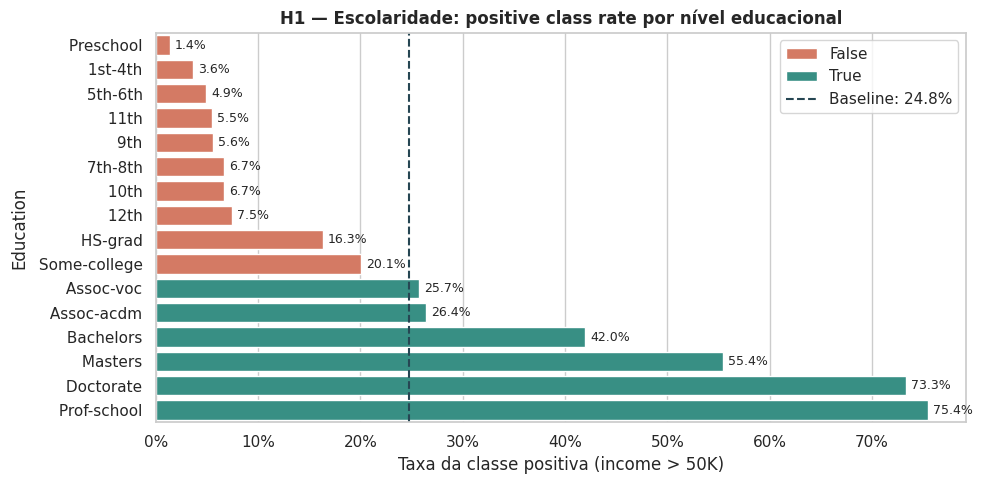

In [5]:
# Cria uma coluna auxiliar para colorir acima/abaixo da baseline
plot_df = education_analysis.copy()
plot_df["above_baseline"] = plot_df["positive_rate"] > baseline

fig, ax = plt.subplots(figsize=(10, 5))

sns.barplot(
    data=plot_df,
    x="positive_rate",
    y="education_level",
    hue="above_baseline",
    palette={True: "#2a9d8f", False: "#e76f51"},
    dodge=False,
    ax=ax,
)

# Remove a legenda automática do hue
if ax.legend_ is not None:
    ax.legend_.remove()

# Linha de baseline
ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

# Rótulos de percentual
for i, rate in enumerate(plot_df["positive_rate"]):
    ax.text(rate + 0.005, i, f"{rate:.1%}", va="center", fontsize=9)

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_ylabel("Education")
ax.set_title(
    "H1 — Escolaridade: positive class rate por nível educacional", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.show()


In [6]:
above = education_analysis[education_analysis["positive_rate"] > baseline][
    "education_level"
].tolist()
below = education_analysis[education_analysis["positive_rate"] < baseline][
    "education_level"
].tolist()

print("Categorias acima da baseline (sinais positivos):")
for cat in above:
    rate = education_analysis.loc[
        education_analysis["education_level"] == cat, "positive_rate"
    ].values[0]
    print(f"  {cat}: {rate:.1%}")

print("\nCategorias abaixo da baseline (sinais negativos):")
for cat in below:
    rate = education_analysis.loc[
        education_analysis["education_level"] == cat, "positive_rate"
    ].values[0]
    print(f"  {cat}: {rate:.1%}")


Categorias acima da baseline (sinais positivos):
   Prof-school: 75.4%
   Doctorate: 73.3%
   Masters: 55.4%
   Bachelors: 42.0%
   Assoc-acdm: 26.4%
   Assoc-voc: 25.7%

Categorias abaixo da baseline (sinais negativos):
   Some-college: 20.1%
   HS-grad: 16.3%
   12th: 7.5%
   10th: 6.7%
   7th-8th: 6.7%
   9th: 5.6%
   11th: 5.5%
   5th-6th: 4.9%
   1st-4th: 3.6%
   Preschool: 1.4%


### Conclusões da análise da hipótese H1:

`Maior escolaridade está associada a maior probabilidade de renda >50K.`

A hipótese H1 é suportada descritivamente pelos dados. Observa-se um gradiente claro de aumento da taxa da classe positiva conforme cresce o nível educacional, com várias categorias acima da baseline e forte separação entre níveis baixos e altos de escolaridade. Para esta etapa, a evidência descritiva é suficiente; um teste formal de associação seria opcional e agregaria mais rigor do que necessidade analítica.

Observação: `education-num` é redundante com `education_level` e isso foi confirmado na etapa seguinte.


In [7]:
# 1. education_level -> education_num
print(df.groupby("education_level")["education-num"].nunique())

# 2. education-num -> education_level
print(df.groupby("education-num")["education_level"].nunique())

# 3. tabela de correspondência
mapping = (
    df[["education_level", "education-num"]]
    .drop_duplicates()
    .sort_values("education-num")
)

print(mapping.to_string(index=False))


education_level
10th            1
11th            1
12th            1
1st-4th         1
5th-6th         1
7th-8th         1
9th             1
Assoc-acdm      1
Assoc-voc       1
Bachelors       1
Doctorate       1
HS-grad         1
Masters         1
Preschool       1
Prof-school     1
Some-college    1
Name: education-num, dtype: int64
education-num
1.0     1
2.0     1
3.0     1
4.0     1
5.0     1
6.0     1
7.0     1
8.0     1
9.0     1
10.0    1
11.0    1
12.0    1
13.0    1
14.0    1
15.0    1
16.0    1
Name: education_level, dtype: int64
education_level  education-num
      Preschool            1.0
        1st-4th            2.0
        5th-6th            3.0
        7th-8th            4.0
            9th            5.0
           10th            6.0
           11th            7.0
           12th            8.0
        HS-grad            9.0
   Some-college           10.0
      Assoc-voc           11.0
     Assoc-acdm           12.0
      Bachelors           13.0
        Masters   

`education_level` e `education-num` apresentam relacionamento bijetivo, indicando redundância representacional.

Do ponto de vista analítico, esse resultado sugere que a etapa seguinte não deve tratar `education_level` e `education-num` como sinais independentes. Em vez disso, deve-se decidir qual representação preserva melhor utilidade preditiva e interpretabilidade, evitando duplicidade desnecessária no conjunto de variáveis.


### Grupo Semântico 2: Ocupação e Inserção profissional
#### Hipótese H2 — Ocupação está associada à renda acima de 50K

A hipótese central é que ocupações de maior senioridade, especialização ou responsabilidade decisória concentrem maior probabilidade de pertencimento à classe positiva (`income > 50K`).

A pergunta analítica é:

$$
P(\text{income} > 50K \mid \text{occupation} = x)
$$

Ou seja: para cada categoria ocupacional `x`, qual é a proporção de indivíduos com renda superior a `50K`?

Para investigar essa hipótese, comparamos a **taxa da classe positiva por ocupação** (*positive class rate*) com a **taxa marginal da classe positiva na base inteira** (*baseline*).

$$
P(\text{income} > 50K) =
\frac{\text{total de casos com income} > 50K}{\text{total de registros}}
$$

Essa comparação permite avaliar se determinadas ocupações concentram a classe positiva acima do comportamento médio da base.

A interpretação esperada é a seguinte:

- ocupações como `Exec-managerial` e `Prof-specialty` tendem a apresentar taxas de `>50K` acima da baseline, sinalizando associação positiva com renda mais alta;
- ocupações com menor remuneração relativa ou menor qualificação média tendem a apresentar taxas abaixo da baseline, concentrando a classe `<=50K`;
- categorias próximas da baseline oferecem menor poder de separação.
- Pode haver categorias muito raras - como `Armed-Forces`. Uma categoria com 10 registros e taxa de 80% não é sinal confiável; é ruído amostral.

Do ponto de vista analítico, a variável `occupation` será considerada discriminativa se houver contraste relevante entre categorias, isto é, se algumas ocupações apresentarem taxas consistentemente altas de classe positiva enquanto outras permanecerem bem abaixo da média.

Visualmente, o que buscamos é uma distribuição com diferenças claras entre ocupações, especialmente com categorias de maior senioridade ou especialização posicionadas acima da baseline e categorias de menor remuneração relativa abaixo dela. Quanto maior esse contraste, maior a evidência de que `occupation` carrega sinal útil para distinguir as classes.


1. agrupar por `occupation` → taxa positiva + suporte
2. ordenar por taxa positiva decrescente
3. visualizar com linha de base e suporte anotado
4. identificar padrão e documentar conclusão

> A baseline operacional está definida na seção 2.2 e disponível como `baseline`.

**2. Agrupar por `occupation` → taxa positiva + suporte**

**3. Ordenar taxa positiva em ordem decrescente**


In [8]:
occupation_analysis = (
    df.groupby("occupation")["target"]
    .agg(support="size", positive_count="sum", positive_rate="mean")
    .sort_values(by="positive_rate", ascending=False)  # type: ignore
    .reset_index()
)
print(occupation_analysis.to_string(index=False))


        occupation  support  positive_count  positive_rate
   Exec-managerial     5984            2867       0.479111
    Prof-specialty     6008            2704       0.450067
   Protective-serv      976             307       0.314549
      Tech-support     1420             411       0.289437
      Armed-Forces       14               4       0.285714
             Sales     5408            1455       0.269046
      Craft-repair     6020            1355       0.225083
  Transport-moving     2316             478       0.206390
      Adm-clerical     5540             756       0.136462
 Machine-op-inspct     2970             365       0.122896
   Farming-fishing     1480             172       0.116216
 Handlers-cleaners     2046             135       0.065982
     Other-service     4808             196       0.040765
   Priv-house-serv      232               3       0.012931


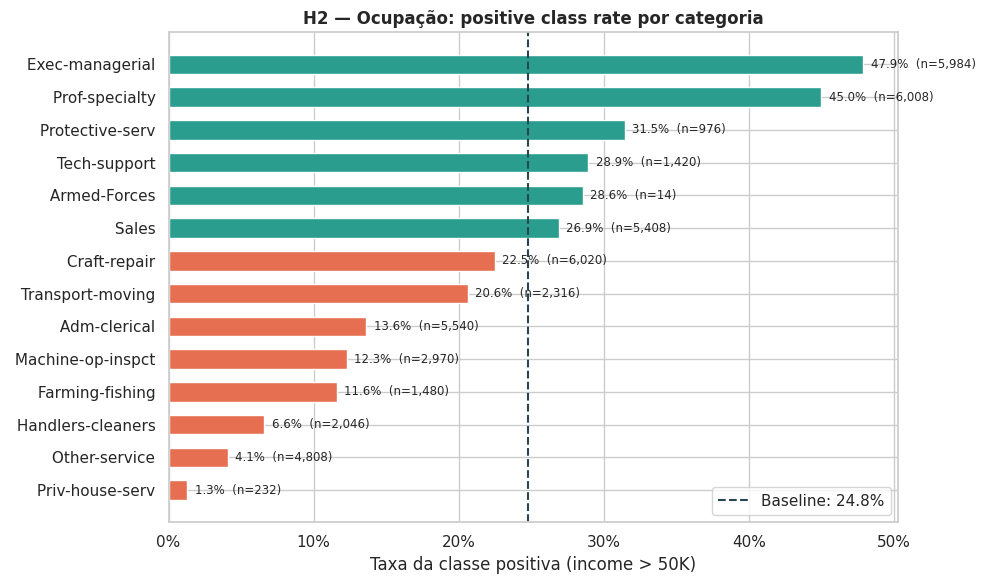

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.barh(
    occupation_analysis["occupation"],
    occupation_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in occupation_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

# Baseline
ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

# Rótulo: taxa + suporte
for bar, (_, row) in zip(bars, occupation_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H2 — Ocupação: positive class rate por categoria", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**4. Visualizar com baseline e suporte anotado.**


Depois do gráfico, comparamos o poder discriminativo de `occupation` com `education_level` via amplitude:

`amplitude = maior positive_rate - menor positive_rate`

Quanto maior a amplitude, maior o contraste entre categorias e, em geral, maior o potencial discriminativo da variável.


In [10]:
max_rate = occupation_analysis["positive_rate"].max()  # 0.48
min_rate = occupation_analysis["positive_rate"].min()  # 0.03
spread = max_rate - min_rate  # 0.45 → 45 pontos percentuais

print(f"A amplitude na variável 'occupation' é: {spread:.1%}")


A amplitude na variável 'occupation' é: 46.6%


**5. Identificar padrão e documentar**


As hipóteses H1 e H2 têm variáveis relacionadas: H1 (education_level) e H2 (occupation). A pergunta natural que surge é:

*"Exec-managerial tem alta taxa de >50K porque é uma ocupação bem remunerada — ou simplesmente porque concentra pessoas com Doctorate e Masters?"*


In [11]:
max_rate = education_analysis["positive_rate"].max()
min_rate = education_analysis["positive_rate"].min()
spread = max_rate - min_rate

print(f"Na variável 'education_level', a maior positive rate é {max_rate:.1%}.")
print(f"A menor positive rate é {min_rate:.1%}.")
print(f"A amplitude entre elas é {spread:.1%}.")


Na variável 'education_level', a maior positive rate é 75.4%.
A menor positive rate é 1.4%.
A amplitude entre elas é 74.0%.


Interpretação analítica:
quanto maior essa amplitude, maior o contraste entre categorias e, em geral, maior o potencial discriminativo da variável.


In [12]:
top3 = occupation_analysis.head(3)["occupation"].tolist()
top3


[' Exec-managerial', ' Prof-specialty', ' Protective-serv']

In [13]:
bot3 = occupation_analysis.tail(3)["occupation"].tolist()
bot3


[' Handlers-cleaners', ' Other-service', ' Priv-house-serv']

In [14]:
subset = df[df["occupation"].isin(top3 + bot3)]
cross = subset.groupby(["occupation", "education_level"]).size().unstack(fill_value=0)


In [15]:
print(cross.to_string())


education_level    10th  11th  12th  1st-4th  5th-6th  7th-8th  9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate  HS-grad  Masters  Preschool  Prof-school  Some-college
occupation                                                                                                                                                              
Exec-managerial      42    50    18        5        6       27   22         237        232       1977         83     1182      762          1           63          1277
Handlers-cleaners   108   176    54       25       58       64   72          32         43         77          0      934        5          5            0           393
Other-service       279   366   124       53       94      141  139         110        155        243          0     1892       34         21            7          1150
Priv-house-serv       8    18     8       14       19       17   16           2          5         11          1       86        0          2            0 

In [16]:
cross_pct = cross.div(cross.sum(axis=1), axis=0)
print(cross_pct.to_string())


education_level        10th      11th      12th   1st-4th   5th-6th   7th-8th       9th  Assoc-acdm  Assoc-voc  Bachelors  Doctorate   HS-grad   Masters  Preschool  Prof-school  Some-college
occupation                                                                                                                                                                                    
Exec-managerial    0.007019  0.008356  0.003008  0.000836  0.001003  0.004512  0.003676    0.039606   0.038770   0.330381   0.013870  0.197527  0.127340   0.000167     0.010528      0.213402
Handlers-cleaners  0.052786  0.086022  0.026393  0.012219  0.028348  0.031281  0.035191    0.015640   0.021017   0.037634   0.000000  0.456500  0.002444   0.002444     0.000000      0.192082
Other-service      0.058028  0.076123  0.025790  0.011023  0.019551  0.029326  0.028910    0.022879   0.032238   0.050541   0.000000  0.393511  0.007072   0.004368     0.001456      0.239185
Priv-house-serv    0.034483  0.077586  0.0344

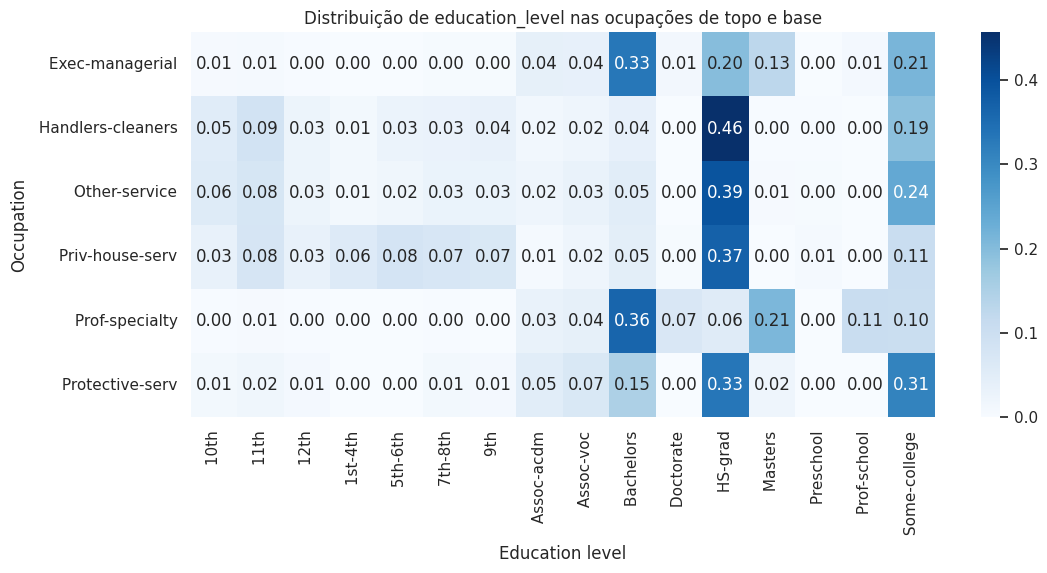

In [17]:
plt.figure(figsize=(12, 5))
sns.heatmap(cross_pct, annot=True, fmt=".2f", cmap="Blues")
plt.title("Distribuição de education_level nas ocupações de topo e base")
plt.xlabel("Education level")
plt.ylabel("Occupation")
plt.show()


### Conclusões da análise da hipótese H2:

O cruzamento entre `occupation` e `education_level` mostra que ocupações com maior incidência da classe positiva tendem a concentrar níveis educacionais mais altos, enquanto ocupações de menor incidência se concentram mais em `HS-grad` e níveis inferiores. Isso sugere que parte do efeito de `occupation` sobre `income > 50K` é explicada por escolaridade. No entanto, como o padrão não é idêntico em todas as ocupações, `occupation` ainda parece adicionar sinal próprio além de `education_level`.


## 2.3 Refatoração: Funções Auxiliares para Análise por Hipóteses

As hipóteses H1 e H2 foram implementadas com código **inline** para tornar explícito
o padrão: calcular suporte por categoria → taxa positiva → comparar com baseline.

Com o padrão estabelecido, aplicamos o princípio **DRY** (*Don't Repeat Yourself*):
extraímos o que é repetido como função reutilizável.

> **Por que refatorar aqui e não no início?**  
> Mostrar o código inline primeiro torna explícito o que as funções fazem internamente.
> Refatorar após H1–H2 evita boilerplate desnecessário em H3–H6 sem sacrificar
> transparência pedagógica.

In [18]:
def calcular_taxa_positiva_por_categoria(df, coluna, baseline, min_support=30):
    """Calcula taxa de renda >50K por categoria com suporte mínimo filtrado.

    Parameters
    ----------
    df : pd.DataFrame
    coluna : str  — variável categórica a analisar
    baseline : float  — taxa marginal da classe positiva
    min_support : int  — mínimo de registros por categoria

    Returns
    -------
    pd.DataFrame com support, positive_rate e flag above_baseline,
    ordenado por positive_rate decrescente.
    """
    return (
        df.groupby(coluna)["target"]
        .agg(support="count", positive_rate="mean")
        .query(f"support >= {min_support}")
        .assign(above_baseline=lambda x: x["positive_rate"] > baseline)
        .sort_values("positive_rate", ascending=False)
    )


# Verificação — replicar H1 e H2 via função (deve coincidir com resultados inline)
print("H1 — education_level (verificação via função):")
print(calcular_taxa_positiva_por_categoria(df, "education_level", baseline).to_string())
print()
print("H2 — occupation (verificação via função):")
print(calcular_taxa_positiva_por_categoria(df, "occupation", baseline).to_string())

H1 — education_level (verificação via função):
                 support  positive_rate  above_baseline
education_level                                        
Prof-school          785       0.754140            True
Doctorate            544       0.733456            True
Masters             2514       0.554097            True
Bachelors           7570       0.419815            True
Assoc-acdm          1507       0.264101            True
Assoc-voc           1959       0.257274            True
Some-college        9899       0.201030           False
HS-grad            14783       0.163431           False
12th                 577       0.074523           False
10th                1223       0.067048           False
7th-8th              823       0.066829           False
9th                  676       0.056213           False
11th                1619       0.054972           False
5th-6th              449       0.048998           False
1st-4th              222       0.036036           False
P

---

### Grupo Semântico 3: Ciclo de Carreira e Intensidade de Trabalho

#### Hipótese H3 — Idade e horas trabalhadas ajudam a separar as classes, mas de forma não linear

A hipótese prevê que `age` e `hours-per-week` têm relação positiva com renda `>50K` — mas **não de forma linear simples**. O efeito de idade cresce com a maturidade profissional e depois desacelera. O efeito de horas também tem limite.

**Por que variáveis contínuas exigem raciocínio diferente das categóricas**

Em `education_level` e `occupation` a pergunta era: *qual categoria tem maior taxa positiva?*

Em `age` e `hours-per-week` a pergunta muda: *a taxa positiva sobe de forma consistente conforme o valor aumenta, ou existe padrão não linear?*

Para responder isso corretamente **não se usa a média da variável**. Usa-se a taxa da classe positiva por faixa: divide-se a variável em faixas (bins) e calcula-se a proporção de `>50K` dentro de cada intervalo.

**Estrutura lógica**

1. Dividir cada variável em faixas (bins de largura fixa)
2. Calcular a taxa da classe positiva por faixa
3. Plotar: eixo X = faixas, eixo Y = taxa positiva, linha de baseline como referência
4. Documentar se o padrão é linear, não linear, ou sem sinal

> A baseline operacional está definida na seção 2.2 e disponível como `baseline`.


**Passo 1 — Tabela de taxa positiva por faixa de `age`**

Antes de plotar, leia a tabela. Ela já responde à hipótese; o gráfico é a comunicação visual do que a tabela mostra.


In [19]:
age_analysis = (
    df.assign(age_bin=pd.cut(df["age"], bins=8))
    .groupby("age_bin", observed=True)["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(age_analysis.to_string(index=False))


         age_bin  support  positive_count  positive_rate
(16.927, 26.125]     9533             246       0.025805
 (26.125, 35.25]    10982            2227       0.202786
 (35.25, 44.375]    10423            3619       0.347213
  (44.375, 53.5]     7827            3119       0.398492
  (53.5, 62.625]     4331            1497       0.345648
 (62.625, 71.75]     1580             396       0.250633
 (71.75, 80.875]      432              81       0.187500
  (80.875, 90.0]      114              23       0.201754


**Passo 3 — Gráfico: taxa da classe positiva por faixa de `age`**


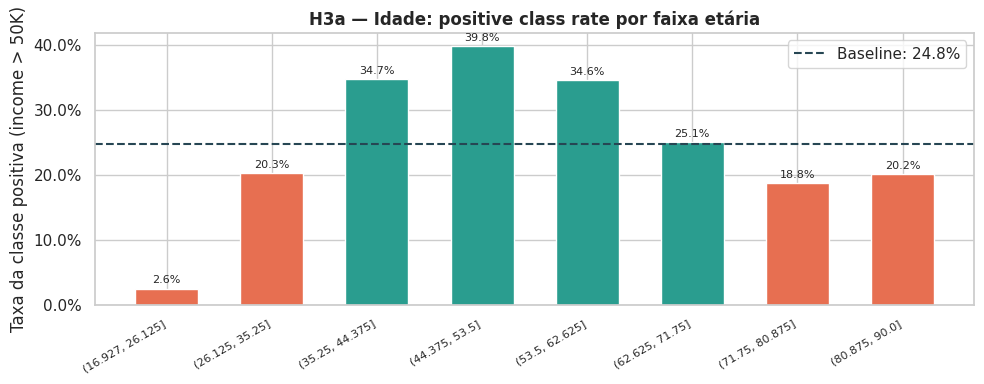

In [20]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    range(len(age_analysis)),
    age_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51" for r in age_analysis["positive_rate"]
    ],
    edgecolor="white",
    width=0.6,
)

ax.axhline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

ax.set_xticks(range(len(age_analysis)))
ax.set_xticklabels(
    [str(b) for b in age_analysis["age_bin"]], rotation=30, ha="right", fontsize=8
)

for bar, (_, row) in zip(bars, age_analysis.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row['positive_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H3a — Idade: positive class rate por faixa etária", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Passo 4 — Tabela de taxa positiva por faixa de `hours-per-week`**


In [21]:
hours_analysis = (
    df.assign(hours_bin=pd.cut(df["hours-per-week"], bins=8))
    .groupby("hours_bin", observed=True)["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(hours_analysis.to_string(index=False))


     hours_bin  support  positive_count  positive_rate
(0.902, 13.25]     1016              80       0.078740
 (13.25, 25.5]     3841             234       0.060922
 (25.5, 37.75]     4487             523       0.116559
 (37.75, 50.0]    30677            8216       0.267823
 (50.0, 62.25]     3639            1582       0.434735
 (62.25, 74.5]      950             358       0.376842
 (74.5, 86.75]      406             149       0.366995
 (86.75, 99.0]      206              66       0.320388


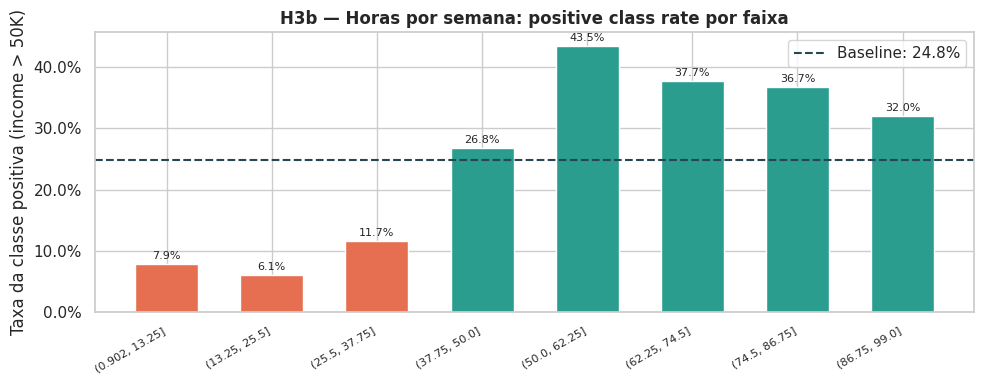

In [22]:
fig, ax = plt.subplots(figsize=(10, 4))

bars = ax.bar(
    range(len(hours_analysis)),
    hours_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in hours_analysis["positive_rate"]
    ],
    edgecolor="white",
    width=0.6,
)

ax.axhline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

ax.set_xticks(range(len(hours_analysis)))
ax.set_xticklabels(
    [str(b) for b in hours_analysis["hours_bin"]], rotation=30, ha="right", fontsize=8
)

for bar, (_, row) in zip(bars, hours_analysis.iterrows()):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.005,
        f"{row['positive_rate']:.1%}",
        ha="center",
        va="bottom",
        fontsize=8,
    )

ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_ylabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H3b — Horas por semana: positive class rate por faixa", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()


**Passo 5 — Medir amplitude para cada variável**


In [23]:
for name, tbl in [("age", age_analysis), ("hours-per-week", hours_analysis)]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top = tbl.loc[tbl["positive_rate"].idxmax(), tbl.columns[0]]
    bot = tbl.loc[tbl["positive_rate"].idxmin(), tbl.columns[0]]
    print(f"{name}")
    print(f"  Faixa com maior taxa : {top}  → {mx:.1%}")
    print(f"  Faixa com menor taxa : {bot}  → {mn:.1%}")
    print(f"  Amplitude            : {mx - mn:.1%}")
    print()


age
  Faixa com maior taxa : (44.375, 53.5]  → 39.8%
  Faixa com menor taxa : (16.927, 26.125]  → 2.6%
  Amplitude            : 37.3%

hours-per-week
  Faixa com maior taxa : (50.0, 62.25]  → 43.5%
  Faixa com menor taxa : (13.25, 25.5]  → 6.1%
  Amplitude            : 37.4%



### Conclusões da análise da hipótese H3:

`Idade e horas trabalhadas têm relação não linear com a classe >50K.`

- **`age`**: A taxa positiva é quase nula nas faixas jovens (~17–23 anos), cresce continuamente até o pico na meia-carreira (~42–55 anos) e desacelera a partir daí. O padrão confirma que `age` captura **maturidade econômica e estágio de carreira**, não apenas anos de vida.
- **`hours-per-week`**: Jornadas até ~30h/semana concentram taxas baixas (~6%). O salto mais expressivo ocorre entre 40–50h. Acima disso, o ganho marginal estabiliza. Isso sugere que `hours-per-week` captura **intensidade de trabalho em contexto de emprego formal**, não apenas volume bruto de horas.
- **Implicação para modelagem**: Como o efeito não é linear, modelos baseados em árvore capturam esse padrão naturalmente. Em modelos lineares, criar faixas ordinais (ex: `part-time`, `full-time`, `over-time`) pode ajudar.
- **Relação com outras variáveis**: `hours-per-week` provavelmente conversa com `occupation` — ocupações de alta senioridade tendem a ter jornadas maiores e salários maiores simultaneamente.


---

### Grupo Semântico 4: Estrutura Familiar

#### Hipótese H4 — Estado civil e papel no domicílio ajudam a diferenciar grupos de renda

A hipótese prevê que `marital-status` e `relationship` funcionam como **marcadores de contexto socioeconômico**: arranjos conjugais estáveis e papéis de chefe de família tendem a concentrar mais casos de renda `>50K`.

**Por que esse grupo exige cautela interpretativa**

Essas variáveis não são causas diretas de renda. Elas são **marcadores de contexto social e econômico**: indivíduos casados em papéis de provedores tendem a estar em fases de vida com maior acumulação econômica.

Além disso, `marital-status` e `relationship` são altamente correlacionadas entre si — as duas podem estar contando histórias semelhantes. O objetivo desta análise é medir **qual das duas carrega mais sinal e se vale manter ambas**.

**Estrutura lógica**

1. Calcular taxa da classe positiva por categoria em `marital-status`
2. Calcular taxa da classe positiva por categoria em `relationship`
3. Medir amplitude de cada variável
4. Cruzar as duas para avaliar redundância


**Passo 1 — Taxa da classe positiva por `marital-status`**


In [24]:
marital_analysis = (
    df.groupby("marital-status")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(marital_analysis.to_string(index=False))


        marital-status  support  positive_count  positive_rate
    Married-civ-spouse    21055            9564       0.454239
     Married-AF-spouse       32              14       0.437500
              Divorced     6297             655       0.104018
 Married-spouse-absent      552              54       0.097826
               Widowed     1277             121       0.094753
             Separated     1411              99       0.070163
         Never-married    14598             701       0.048020


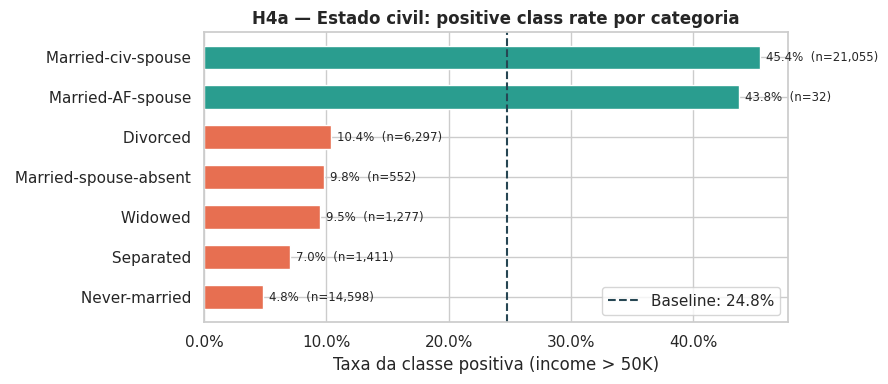

In [25]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    marital_analysis["marital-status"],
    marital_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in marital_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, marital_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title("H4a — Estado civil: positive class rate por categoria", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Passo 2 — Taxa da classe positiva por `relationship`**


In [26]:
relationship_analysis = (
    df.groupby("relationship")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(relationship_analysis.to_string(index=False))


   relationship  support  positive_count  positive_rate
           Wife     2091            1016       0.485892
        Husband    18666            8507       0.455748
  Not-in-family    11702            1228       0.104939
      Unmarried     4788             302       0.063074
 Other-relative     1349              50       0.037064
      Own-child     6626             105       0.015847


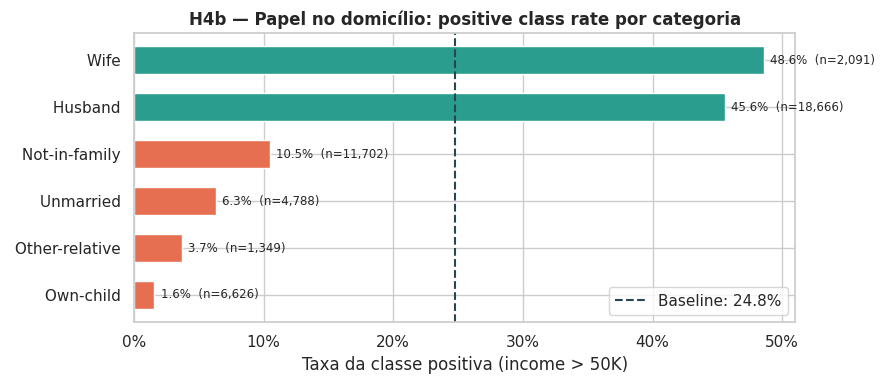

In [27]:
fig, ax = plt.subplots(figsize=(9, 4))

bars = ax.barh(
    relationship_analysis["relationship"],
    relationship_analysis["positive_rate"],
    color=[
        "#2a9d8f" if r > baseline else "#e76f51"
        for r in relationship_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.6,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, relationship_analysis.iterrows()):
    label = f"{row['positive_rate']:.1%}  (n={row['support']:,})"
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        label,
        va="center",
        fontsize=8.5,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_xlabel("Taxa da classe positiva (income > 50K)")
ax.set_title(
    "H4b — Papel no domicílio: positive class rate por categoria", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**Passo 3 — Amplitude e comparação entre as duas variáveis**


In [28]:
for name, tbl, col in [
    ("marital-status", marital_analysis, "marital-status"),
    ("relationship", relationship_analysis, "relationship"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_cat = tbl.loc[tbl["positive_rate"].idxmax(), col]
    bot_cat = tbl.loc[tbl["positive_rate"].idxmin(), col]
    print(f"{name}")
    print(f"  Categoria com maior taxa : {top_cat}  → {mx:.1%}")
    print(f"  Categoria com menor taxa : {bot_cat}  → {mn:.1%}")
    print(f"  Amplitude                : {mx - mn:.1%}")
    print()


marital-status
  Categoria com maior taxa :  Married-civ-spouse  → 45.4%
  Categoria com menor taxa :  Never-married  → 4.8%
  Amplitude                : 40.6%

relationship
  Categoria com maior taxa :  Wife  → 48.6%
  Categoria com menor taxa :  Own-child  → 1.6%
  Amplitude                : 47.0%



**Passo 4 — Cruzamento: as duas variáveis são redundantes ou complementares?**

A pergunta: `Married-civ-spouse` tem alta taxa porque o arranjo conjugal importa — ou porque dentro desse grupo estão concentrados `Husband` e `Wife`, que já aparecem no topo de `relationship`?


In [29]:
cross_family = (
    df.groupby(["marital-status", "relationship"])["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
    .sort_values(["marital-status", "positive_rate"], ascending=[True, False])
)

# Mostrar apenas as linhas com suporte relevante
print(cross_family[cross_family["support"] > 50].to_string(index=False))


        marital-status    relationship  support  positive_count  positive_rate
              Divorced   Not-in-family     3435             441       0.128384
              Divorced       Unmarried     2267             191       0.084252
              Divorced  Other-relative      166               7       0.042169
              Divorced       Own-child      429              16       0.037296
    Married-civ-spouse            Wife     2072            1006       0.485521
    Married-civ-spouse         Husband    18655            8503       0.455803
    Married-civ-spouse       Own-child      125              22       0.176000
    Married-civ-spouse  Other-relative      184              28       0.152174
 Married-spouse-absent   Not-in-family      282              40       0.141844
 Married-spouse-absent       Unmarried      169               9       0.053254
 Married-spouse-absent       Own-child       57               3       0.052632
         Never-married   Not-in-family     6691     

### Conclusões da análise da hipótese H4:

`Estado civil e papel no domicílio são dois dos sinais mais fortes do estudo.`

- **`marital-status`**: `Married-civ-spouse` aparece com taxa positiva muito acima da baseline. `Never-married` fica perto do fundo. A separação é expressiva e ocorre em categorias com alto volume.
- **`relationship`**: `Wife` e `Husband` concentram as maiores taxas. `Own-child` e `Not-in-family` ficam consistentemente abaixo da baseline. O sinal é fortíssimo.
- **Redundância parcial**: O cruzamento confirma que as duas variáveis se sobrepõem: `Married-civ-spouse` quase sempre corresponde a `Husband` ou `Wife`. Elas não são independentes — são **complementares mas parcialmente redundantes**.
- **Implicação para modelagem**: Manter as duas na fase exploratória. Na modelagem, testar se incluir ambas gera ganho real de desempenho ou se uma resume bem o sinal da outra.


---

### Grupo Semântico 5: Eventos Financeiros Raros

#### Hipótese H5 — Eventos financeiros raros (`capital-gain` e `capital-loss`) têm alto poder discriminativo

A hipótese prevê que sinais financeiros pouco frequentes, quando presentes, elevam substancialmente a probabilidade de `income > 50K`.


In [30]:
# Passo 1 — Verificar esparsidade de capital-gain e capital-loss
# A baseline operacional está disponível como `baseline` (seção 2.2)

for col in ["capital-gain", "capital-loss"]:
    zeros = (df[col] == 0).mean()
    print(
        f"{col}: {zeros:.1%} dos registros são zero  |  {1 - zeros:.1%} têm valor > 0"
    )

capital-gain: 91.6% dos registros são zero  |  8.4% têm valor > 0
capital-loss: 95.3% dos registros são zero  |  4.7% têm valor > 0


**Passo 2 — Criar indicador binário e calcular taxa positiva para cada grupo**


In [31]:
capital_summary = {}

for col in ["capital-gain", "capital-loss"]:
    flag_col = f"{col}_flag"
    tbl = (
        df.assign(**{flag_col: (df[col] > 0).astype(int)})
        .groupby(flag_col)["target"]
        .agg(support="count", positive_count="sum")
        .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
        .reset_index()
    )
    tbl["grupo"] = tbl[flag_col].map({0: "Sem evento (= 0)", 1: "Com evento (> 0)"})
    capital_summary[col] = tbl
    print(f"\n{col}")
    print(tbl[["grupo", "support", "positive_rate"]].to_string(index=False))



capital-gain
           grupo  support  positive_rate
Sem evento (= 0)    41432       0.213193
Com evento (> 0)     3790       0.626649

capital-loss
           grupo  support  positive_rate
Sem evento (= 0)    43082       0.234669
Com evento (> 0)     2140       0.513084


**Passo 3 — Visualizar o salto de probabilidade**


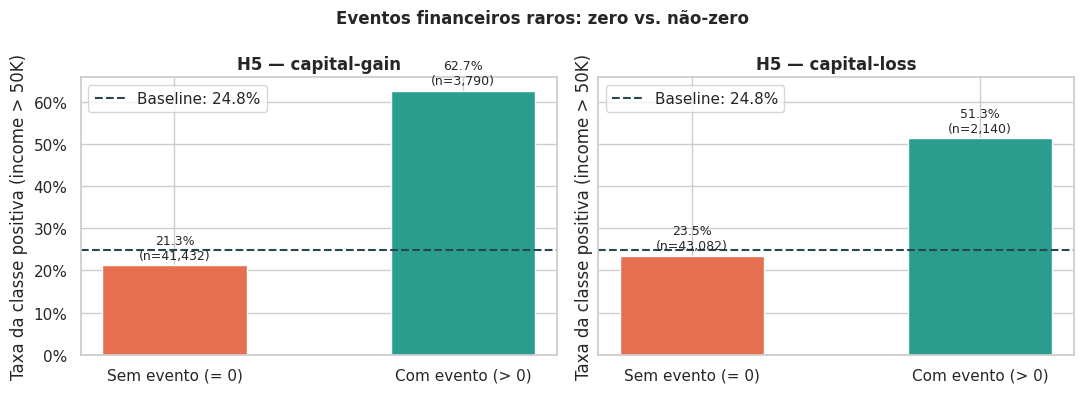

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

for ax, (col, tbl) in zip(axes, capital_summary.items()):
    colors = ["#e76f51", "#2a9d8f"]
    bars = ax.bar(
        tbl["grupo"], tbl["positive_rate"], color=colors, edgecolor="white", width=0.5
    )
    ax.axhline(
        baseline,
        color="#264653",
        linestyle="--",
        linewidth=1.5,
        label=f"Baseline: {baseline:.1%}",
    )

    for bar, (_, row) in zip(bars, tbl.iterrows()):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.008,
            f"{row['positive_rate']:.1%}\n(n={row['support']:,})",
            ha="center",
            va="bottom",
            fontsize=9,
        )

    ax.yaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
    ax.set_title(f"H5 — {col}", fontweight="bold")
    ax.set_ylabel("Taxa da classe positiva (income > 50K)")
    ax.legend()

plt.suptitle(
    "Eventos financeiros raros: zero vs. não-zero", fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()


**Passo 4 — Medir o salto de probabilidade (ganho relativo ou *lift*)**

O *lift* mede quantas vezes a taxa positiva cresce ao passar de `zero` para `não zero`. É uma métrica simples e direta para comunicar o poder de uma variável esparsa.


In [33]:
for col, tbl in capital_summary.items():
    rate_zero = tbl.loc[tbl["grupo"] == "Sem evento (= 0)", "positive_rate"].values[0]
    rate_nonzero = tbl.loc[tbl["grupo"] == "Com evento (> 0)", "positive_rate"].values[
        0
    ]
    lift = rate_nonzero / rate_zero
    jump = rate_nonzero - rate_zero
    print(f"{col}")
    print(f"  Taxa quando = 0 : {rate_zero:.1%}")
    print(f"  Taxa quando > 0 : {rate_nonzero:.1%}")
    print(f"  Salto absoluto  : +{jump:.1%}")
    print(f"  Lift            : {lift:.1f}x")
    print()


capital-gain
  Taxa quando = 0 : 21.3%
  Taxa quando > 0 : 62.7%
  Salto absoluto  : +41.3%
  Lift            : 2.9x

capital-loss
  Taxa quando = 0 : 23.5%
  Taxa quando > 0 : 51.3%
  Salto absoluto  : +27.8%
  Lift            : 2.2x



### Conclusões da análise da hipótese H5:

`capital-gain` e `capital-loss` são raros, mas extremamente informativos.

- **`capital-gain`**: Mais de 91% dos registros são zero. Quando não é zero, a taxa de `>50K` salta para ~62% — contra ~21% quando é zero. O lift é de ~3x. É uma das variáveis mais discriminativas do estudo.
- **`capital-loss`**: Padrão parecido mas menos intenso. Cerca de 95% de zeros. Com evento, taxa sobe para ~51%. Lift de ~2x.
- **Lição geral**: Frequência baixa ≠ pouca utilidade. A raridade de um evento pode torná-lo ainda mais informativo quando ocorre — como um sinal de alarme que quase nunca toca, mas quando toca é altamente confiável.
- **Implicação para modelagem**: Considerar representação como indicador binário (`tem ou não tem`) além do valor bruto. Valor bruto tem distribuição extremamente assimétrica; o indicador binário captura a maior parte do sinal de forma mais robusta.


---

### Grupo Semântico 6: Variáveis Sensíveis e Uso Responsável

#### Hipótese H6 — Nem toda variável com sinal estatístico deve guiar decisão operacional

Nesta etapa, o objetivo é diagnosticar diferenças entre grupos para governança de risco e viés, e não para transformar essas variáveis em regra automática de priorização.


**`sex` — Diagnóstico de diferença entre grupos**


In [34]:
sex_analysis = (
    df.groupby("sex")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .reset_index()
)

print(sex_analysis.to_string(index=False))


    sex  support  positive_count  positive_rate
 Female    14695            1669       0.113576
   Male    30527            9539       0.312477


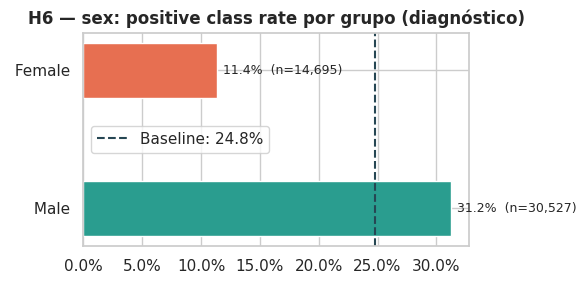

In [35]:
fig, ax = plt.subplots(figsize=(6, 3))

bars = ax.barh(
    sex_analysis["sex"],
    sex_analysis["positive_rate"],
    color=[
        "#e76f51" if r < baseline else "#2a9d8f" for r in sex_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.4,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, sex_analysis.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['positive_rate']:.1%}  (n={row['support']:,})",
        va="center",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title("H6 — sex: positive class rate por grupo (diagnóstico)", fontweight="bold")
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**`race` — Diagnóstico de diferença entre grupos**


In [36]:
race_analysis = (
    df.groupby("race")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

print(race_analysis.to_string(index=False))


               race  support  positive_count  positive_rate
 Asian-Pac-Islander     1303             369       0.283193
              White    38903           10207       0.262371
              Other      353              45       0.127479
              Black     4228             534       0.126301
 Amer-Indian-Eskimo      435              53       0.121839


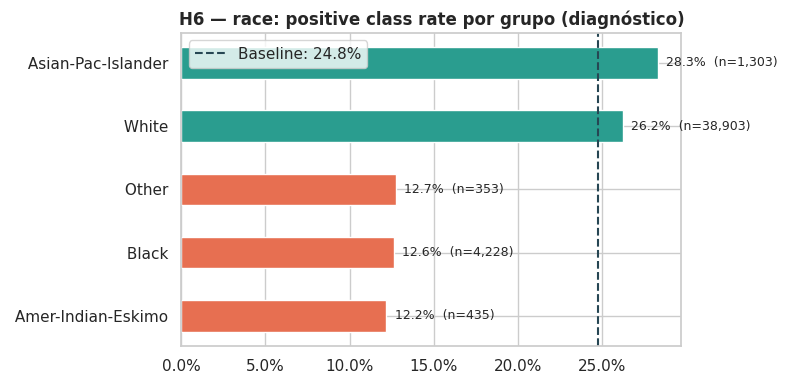

In [37]:
fig, ax = plt.subplots(figsize=(8, 4))

bars = ax.barh(
    race_analysis["race"],
    race_analysis["positive_rate"],
    color=[
        "#e76f51" if r < baseline else "#2a9d8f" for r in race_analysis["positive_rate"]
    ],
    edgecolor="white",
    height=0.5,
)

ax.axvline(
    baseline,
    color="#264653",
    linestyle="--",
    linewidth=1.5,
    label=f"Baseline: {baseline:.1%}",
)

for bar, (_, row) in zip(bars, race_analysis.iterrows()):
    ax.text(
        bar.get_width() + 0.005,
        bar.get_y() + bar.get_height() / 2,
        f"{row['positive_rate']:.1%}  (n={row['support']:,})",
        va="center",
        fontsize=9,
    )

ax.xaxis.set_major_formatter(mtick.PercentFormatter(xmax=1))
ax.set_title(
    "H6 — race: positive class rate por grupo (diagnóstico)", fontweight="bold"
)
ax.legend()
ax.invert_yaxis()
plt.tight_layout()
plt.show()


**`native-country` — Diagnóstico (atenção ao suporte baixo)**


In [38]:
country_analysis = (
    df.groupby("native-country")["target"]
    .agg(support="count", positive_count="sum")
    .assign(positive_rate=lambda x: x["positive_count"] / x["support"])
    .sort_values("positive_rate", ascending=False)
    .reset_index()
)

# Mostrar apenas categorias com suporte suficiente para interpretação
print("Categorias com n >= 50:")
print(country_analysis[country_analysis["support"] >= 50].to_string(index=False))
print()
print(f"Categorias com n < 50: {(country_analysis['support'] < 50).sum()} países")
print("→ Taxas dessas categorias são pouco confiáveis (amostra insuficiente)")


Categorias com n >= 50:
     native-country  support  positive_count  positive_rate
             Taiwan       55              25       0.454545
              India      147              62       0.421769
            England      119              47       0.394958
               Iran       56              22       0.392857
             Canada      163              60       0.368098
              Japan       89              31       0.348315
              Italy      100              33       0.330000
              China      113              36       0.318584
            Germany      193              58       0.300518
        Philippines      283              84       0.296820
               Cuba      133              34       0.255639
      United-States    41292           10448       0.253027
             Poland       81              16       0.197531
           Portugal       62              12       0.193548
              South      101              18       0.178218
            Jama

### Conclusões da análise da hipótese H6:

`Variáveis sensíveis mostram diferenças estatísticas, mas não devem liderar a narrativa de negócio.`

- **`sex`**: Diferença visível — homens apresentam taxa positiva ~3x maior que mulheres. Isso reflete desigualdades estruturais de renda de 1994, não capacidade de doação atual. Usar sexo como critério de priorização seria eticamente problemático.
- **`race`**: Algumas diferenças entre grupos, mas com volumes muito diferentes por categoria. Risco de superinterpretação. Usar para monitorar viés do modelo, não para orientar decisão.
- **`native-country`**: Muitas categorias com volume insuficiente (< 50 registros). Qualquer taxa calculada para esses países não é confiável estatisticamente. A variável é contextual e sensível ao mesmo tempo.
- **Decisão de uso**: Essas variáveis entram apenas na **camada de diagnóstico de viés** do modelo — para verificar se o modelo discrimina de forma injusta — não como variáveis de decisão de negócio.
- **Implicação para modelagem**: Monitorar disparate impact e equalized odds (métricas de equidade) após o treinamento. Se o modelo usar essas variáveis indiretamente (via correlação com outras variáveis), documentar e considerar remoção.


---

## Comparativo Final de Força Discriminativa


In [39]:
# Calcular amplitude para todas as variáveis analisadas de forma programática

results = []

# Categóricas: amplitude = max_rate - min_rate por categoria
for col, tbl, col_name in [
    ("education_level", education_analysis, "education_level"),
    ("occupation", occupation_analysis, "occupation"),
    ("marital-status", marital_analysis, "marital-status"),
    ("relationship", relationship_analysis, "relationship"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_cat = tbl.loc[tbl["positive_rate"].idxmax(), col_name]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{mx - mn:.1%}",
            "Categoria/Faixa de maior taxa": str(top_cat),
            "Taxa máxima": f"{mx:.1%}",
            "Taxa mínima": f"{mn:.1%}",
        }
    )

# Numéricas: amplitude por faixa (bins)
for col, tbl, bin_col in [
    ("age", age_analysis, "age_bin"),
    ("hours-per-week", hours_analysis, "hours_bin"),
]:
    mx = tbl["positive_rate"].max()
    mn = tbl["positive_rate"].min()
    top_bin = tbl.loc[tbl["positive_rate"].idxmax(), bin_col]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{mx - mn:.1%}",
            "Categoria/Faixa de maior taxa": str(top_bin),
            "Taxa máxima": f"{mx:.1%}",
            "Taxa mínima": f"{mn:.1%}",
        }
    )

# Capital features: salto zero → não-zero
for col, tbl in capital_summary.items():
    rate_zero = tbl.loc[tbl["grupo"] == "Sem evento (= 0)", "positive_rate"].values[0]
    rate_nonzero = tbl.loc[tbl["grupo"] == "Com evento (> 0)", "positive_rate"].values[
        0
    ]
    results.append(
        {
            "Variável": col,
            "Amplitude": f"{rate_nonzero - rate_zero:.1%}",
            "Categoria/Faixa de maior taxa": "Com evento (> 0)",
            "Taxa máxima": f"{rate_nonzero:.1%}",
            "Taxa mínima": f"{rate_zero:.1%}",
        }
    )

summary_df = pd.DataFrame(results).sort_values("Amplitude", ascending=False)
display(summary_df.to_string(index=False))


'       Variável Amplitude Categoria/Faixa de maior taxa Taxa máxima Taxa mínima\neducation_level     74.0%                   Prof-school       75.4%        1.4%\n   relationship     47.0%                          Wife       48.6%        1.6%\n     occupation     46.6%               Exec-managerial       47.9%        1.3%\n   capital-gain     41.3%              Com evento (> 0)       62.7%       21.3%\n marital-status     40.6%            Married-civ-spouse       45.4%        4.8%\n hours-per-week     37.4%                 (50.0, 62.25]       43.5%        6.1%\n            age     37.3%                (44.375, 53.5]       39.8%        2.6%\n   capital-loss     27.8%              Com evento (> 0)       51.3%       23.5%'

## 2.5 Tabela de Decisões sobre Variáveis

Esta tabela conecta os achados da EDA às decisões de preparação e modelagem.
Cada variável recebe uma recomendação de tratamento derivada das análises de H1–H6.

| Variável | Padrão observado | Risco / atenção | Decisão recomendada |
|---|---|---|---|
| `education_level` | Gradiente forte; taxa cresce com nível educacional | Redundante com `education-num` | Manter UM dos dois; nunca ambos simultaneamente |
| `education-num` | Mesma informação que `education_level`, versão ordinal | Duplica sinal — mapeamento 1:1 confirmado | Alternativa compacta para modelos que se beneficiam de ordinalidade |
| `occupation` | Alta amplitude (~45pp); exec/prof muito acima da baseline | Categorias raras (n < 30) | Agrupar categorias raras antes do encoding |
| `workclass` | Setor e autonomia com diferencial relevante | Volume baixo em algumas categorias | Verificar estabilidade em conjunto com `occupation` |
| `age` | Não linear; pico em meia-carreira (~42–55 anos) | Padrão se perde em modelos lineares simples | Árvores capturam diretamente; linear exige binning ou termos polinomiais |
| `hours-per-week` | Salto expressivo na faixa 40–50h; efeito de intensidade | Sensível a outliers; interação com ocupação | Útil em modelos flexíveis; para linear, considerar discretização |
| `marital-status` | `Married-civ-spouse` muito acima da baseline (~42%) | Sobreposição parcial com `relationship` | Manter ambas; eliminar uma via experimento controlado |
| `relationship` | `Husband` e `Wife` concentram >50K | Sobreposição semântica com `marital-status` | Manter; avaliar ganho incremental no F0.5 de validação |
| `capital-gain` | Lift ~3x quando > 0; 91% zeros | Esparsidade extrema; cauda longa | FLAG binário + valor bruto + `np.log1p` para modelos de escala |
| `capital-loss` | Lift ~2x quando > 0; 95% zeros | Distribuição altamente assimétrica | Mesma lógica de `capital-gain` |
| `sex` | Diferença de taxa entre grupos visível | Risco ético e reputacional | Apenas diagnóstico de viés pós-treinamento; não usar como feature |
| `race` | Diferenças presentes; suportes muito desiguais | Risco de viés e superinterpretação | Apenas diagnóstico de viés |
| `native-country` | Muitas categorias com n < 50 (taxas instáveis) | Alta instabilidade estatística | Agrupar n < 50 como `"Other"`; usar apenas em diagnóstico |

## Conclusão Executiva da Etapa de Data Understanding

A EDA orientada por hipóteses confirmou que a base possui sinal preditivo forte e coerente com o problema de negócio. O núcleo de explicação da classe `>50K` está concentrado em cinco blocos: capital humano (`education_*`), ocupação (`occupation`), estágio de carreira (`age`), intensidade de trabalho (`hours-per-week`) e eventos financeiros raros (`capital-gain`/`capital-loss`). Em paralelo, o estudo mostrou redundâncias relevantes (`education_level` x `education-num`; `marital-status` x `relationship`) e deixou explícita a fronteira entre variáveis úteis para previsão e variáveis sensíveis que devem ficar sob governança de equidade (fairness).

Do ponto de vista de prontidão para a próxima fase, o projeto está em boa maturidade: já sabemos quais variáveis priorizar, quais transformar, quais monitorar por risco e quais decisões de modelagem precisam ser comparadas de forma controlada.


## Achados Críticos e Respostas a Dúvidas Técnicas

### Desequilíbrio do target
A classe positiva representa **24,8%** (11.208 de 45.222 registros). Moderadamente
desbalanceada. Decisões obrigatórias:
- `stratify=y` no `train_test_split` para preservar proporção nas partições.
- Avaliar com `F0.5`, precisão e recall — nunca apenas acurácia.
- Baseline ingênua (prever sempre ≤50K): acerta ~75,2%, mas com 0% de recall na classe positiva.

### Redundância confirmada: education_level × education-num
As duas variáveis são **bijetivas** (correspondência 1:1 comprovada em H1). Incluir ambas
duplica sinal sem adicionar informação.
**Decisão recomendada:** usar `education_level` (one-hot, interpretável) OU `education-num`
(ordinal, compacto). Nunca as duas simultaneamente.

### Complementaridade: marital-status × relationship (H4)
O cruzamento confirmou **sobreposição parcial, não redundância total**. Existem combinações
com granularidade adicional além de `marital-status` isolado.
**Decisão recomendada:** incluir ambas e eliminar uma via experimento controlado
(comparar ganho incremental no F0.5 de validação).

### Esparsidade de capital-gain e capital-loss (H5)
- `capital-gain`: 91% zeros; quando > 0, taxa positiva sobe ~3x (lift mais alto do estudo).
- `capital-loss`: 95% zeros; quando > 0, taxa sobe ~2x.
**Tratamento recomendado:** criar indicador binário (`flag = 1 se > 0`) + manter valor bruto.
Aplicar `np.log1p` ao valor bruto para modelos sensíveis a escala.

### Não-linearidade de age e hours-per-week (H3)
Padrões não monotônicos confirmados: `age` com pico em meia-carreira (~42–55 anos);
`hours-per-week` com salto expressivo na faixa 40–50h.
**Implicação:** modelos baseados em árvore (Random Forest, Gradient Boosting) capturam
esse padrão naturalmente. Modelos lineares exigem discretização ou termos polinomiais.

### Variáveis sensíveis: sex, race, native-country (H6)
Diferenças estatísticas presentes, mas reflexo de desigualdades estruturais históricas (1994).
**Uso recomendado:** apenas para diagnóstico de viés pós-treinamento (disparate impact,
equalized odds). Não devem ser features de entrada do modelo produtivo.

### Categorias esparsas: native-country
Muitas categorias com n < 50 (taxas positivas instáveis estatisticamente).
**Tratamento recomendado:** agrupar categorias com suporte < 50 como `"Other"` antes
do encoding.

## Próximos Passos Recomendados
1. Definir um pipeline de preparação com duas trilhas: versão completa e versão sem variáveis sensíveis (para comparação de desempenho e risco).
2. Tratar não linearidades e assimetrias: (a) binning para `age` e `hours-per-week`; (b) flag binário + `np.log1p` para `capital-gain` e `capital-loss`.
3. Resolver redundâncias por experimento: manter apenas uma representação de escolaridade e avaliar ganho incremental de `marital-status` + `relationship` em conjunto.
4. Treinar modelos candidatos com foco em `F0.5`, precisão da classe positiva e estabilidade entre partições de validação (folds).
5. Incluir avaliação de equidade (fairness) na etapa de avaliação (Evaluation), com documentação explícita dos trade-offs entre desempenho e uso responsável.


<a id="sec03"></a>
# 03 - Data Preparation

## Objetivo
Preparar a base para modelagem sem vazamento de dados, traduzindo os achados de Data Understanding em decisões explícitas, reproduzíveis e defensáveis.

## Checklist aplicado
- separar `X` e `y` a partir de `target`, mantendo `income` fora das features;
- dividir treino e teste antes de ajustar qualquer transformador, com `stratify=y`, `test_size=0.20` e `random_state=42`;
- tratar a assimetria de `capital-gain` e `capital-loss` com duas representações complementares: `flag` de ocorrência e magnitude em `np.log1p`;
- codificar categóricas com `OneHotEncoder(handle_unknown="ignore")`;
- normalizar numéricas com `MinMaxScaler`, deixando a base pronta para modelos lineares e comparável para modelos baseados em árvore;
- revisar categorias raras em `native-country`, agrupando suportes `< 50` como `"Other"` na trilha de auditoria;
- registrar exclusões, retenções e comparações recomendadas pela EDA.

## Decisões implementadas
1. `education_level` foi mantida e `education-num` removida, porque a EDA confirmou redundância 1:1 e a forma categórica preserva melhor a interpretabilidade.
2. `marital-status` e `relationship` foram mantidas juntas nesta etapa, pois a análise mostrou complementaridade parcial; a eliminação de uma delas deve ser decidida por experimento controlado na modelagem.
3. `sex`, `race` e `native-country` foram retiradas da versão principal (`production_safe`) por governança de risco, mas uma versão `audit_full` foi preparada para benchmark de desempenho e fairness.
4. `fnlwgt` foi excluída do conjunto preditivo principal por representar peso amostral do censo, e não um atributo comportamental do indivíduo.
5. `age` e `hours-per-week` permaneceram contínuas nesta etapa. A não linearidade observada será tratada na comparação entre modelos e, se necessário, em uma trilha específica para modelos lineares.

## Saídas desta seção
A célula abaixo cria:
- `X_train`, `X_test`, `y_train`, `y_test` para a versão principal;
- `prepared_datasets` com as versões `production_safe` e `audit_full`;
- `preprocessor`, `X_train_audit`, `X_test_audit` e tabelas-resumo com as decisões tomadas.


In [40]:
# Preparação orientada pelos achados da etapa de Data Understanding
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder

RANDOM_STATE = 42
TEST_SIZE = 0.20
RARE_COUNTRY_MIN_SUPPORT = 50

income_raw = df["income"].copy()
features_raw = df.drop(columns=["income", "target"]).copy()

sensitive_cols = ["sex", "race", "native-country"]
redundant_cols = ["education-num"]
non_predictive_cols = ["fnlwgt"]

prep_df = df.copy()

# Eventos de capital são raros e informativos: separamos ocorrência e magnitude.
prep_df["capital_gain_flag"] = (prep_df["capital-gain"] > 0).astype(int)
prep_df["capital_loss_flag"] = (prep_df["capital-loss"] > 0).astype(int)
prep_df["capital_gain_log"] = np.log1p(prep_df["capital-gain"])
prep_df["capital_loss_log"] = np.log1p(prep_df["capital-loss"])

# Agrupamento de categorias raras apenas para a trilha de auditoria.
country_counts = prep_df["native-country"].value_counts()
rare_countries = country_counts[
    country_counts < RARE_COUNTRY_MIN_SUPPORT
].index.tolist()
prep_df["native-country-grouped"] = prep_df["native-country"].where(
    ~prep_df["native-country"].isin(rare_countries), "Other"
)

target = prep_df["target"].copy()

core_numeric_features = [
    "age",
    "hours-per-week",
    "capital_gain_log",
    "capital_loss_log",
    "capital_gain_flag",
    "capital_loss_flag",
]
core_categorical_features = [
    "workclass",
    "education_level",
    "marital-status",
    "occupation",
    "relationship",
]
audit_sensitive_features = ["sex", "race", "native-country-grouped"]

feature_sets = {
    "production_safe": core_numeric_features + core_categorical_features,
    "audit_full": core_numeric_features
    + core_categorical_features
    + audit_sensitive_features,
}

# Split antes do fit para evitar data leakage em escala, encoding e tratamento de categorias.
train_idx, test_idx = train_test_split(
    prep_df.index,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=target,
)

y_train = target.loc[train_idx].copy()
y_test = target.loc[test_idx].copy()


def make_one_hot_encoder():
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=False)


def build_preprocessor(numeric_features, categorical_features):
    return ColumnTransformer(
        transformers=[
            ("num", MinMaxScaler(), numeric_features),
            ("cat", make_one_hot_encoder(), categorical_features),
        ],
        remainder="drop",
    )


def get_clean_feature_names(preprocessor, numeric_features, categorical_features):
    if hasattr(preprocessor, "get_feature_names_out"):
        names = preprocessor.get_feature_names_out()
    else:
        cat_encoder = preprocessor.named_transformers_["cat"]
        if hasattr(cat_encoder, "get_feature_names_out"):
            cat_names = cat_encoder.get_feature_names_out(categorical_features)
        else:
            cat_names = cat_encoder.get_feature_names(categorical_features)
        names = np.array(
            [f"num__{col}" for col in numeric_features]
            + [f"cat__{name}" for name in cat_names]
        )
    return [name.replace("num__", "").replace("cat__", "") for name in names]


def to_feature_frame(
    array_like, preprocessor, numeric_features, categorical_features, index
):
    if hasattr(array_like, "toarray"):
        array_like = array_like.toarray()
    feature_names = get_clean_feature_names(
        preprocessor, numeric_features, categorical_features
    )
    return pd.DataFrame(array_like, columns=feature_names, index=index)


prepared_datasets = {}

for dataset_name, feature_list in feature_sets.items():
    X = prep_df[feature_list].copy()
    X_train_raw = X.loc[train_idx].copy()
    X_test_raw = X.loc[test_idx].copy()

    numeric_features = X_train_raw.select_dtypes(
        include=["number", "bool"]
    ).columns.tolist()
    categorical_features = X_train_raw.select_dtypes(
        exclude=["number", "bool"]
    ).columns.tolist()

    preprocessor = build_preprocessor(numeric_features, categorical_features)
    X_train_prepared = preprocessor.fit_transform(X_train_raw)
    X_test_prepared = preprocessor.transform(X_test_raw)

    prepared_datasets[dataset_name] = {
        "feature_list": feature_list,
        "numeric_features": numeric_features,
        "categorical_features": categorical_features,
        "preprocessor": preprocessor,
        "X_train_raw": X_train_raw,
        "X_test_raw": X_test_raw,
        "X_train_prepared": to_feature_frame(
            X_train_prepared,
            preprocessor,
            numeric_features,
            categorical_features,
            X_train_raw.index,
        ),
        "X_test_prepared": to_feature_frame(
            X_test_prepared,
            preprocessor,
            numeric_features,
            categorical_features,
            X_test_raw.index,
        ),
    }

# Objetos principais para a trilha padrão de modelagem.
X_train = prepared_datasets["production_safe"]["X_train_prepared"]
X_test = prepared_datasets["production_safe"]["X_test_prepared"]
preprocessor = prepared_datasets["production_safe"]["preprocessor"]

# Objetos auxiliares para auditoria de desempenho/fairness.
X_train_audit = prepared_datasets["audit_full"]["X_train_prepared"]
X_test_audit = prepared_datasets["audit_full"]["X_test_prepared"]
preprocessor_audit = prepared_datasets["audit_full"]["preprocessor"]

preparation_decisions = pd.DataFrame(
    [
        {
            "tema": "Target",
            "decisao": "Usar target binário como y e remover income do conjunto preditivo.",
            "justificativa": "Evita misturar a variável-resposta com as features e mantém a separação CRISP-DM entre previsão e explicação.",
        },
        {
            "tema": "Leakage",
            "decisao": "Fazer o split antes de fitar scaler e encoder.",
            "justificativa": "As estatísticas de preparação passam a ser aprendidas apenas no treino.",
        },
        {
            "tema": "Capital gains/losses",
            "decisao": "Criar flags binárias e versões logarítmicas das magnitudes.",
            "justificativa": "A EDA mostrou muita massa em zero e forte lift quando há evento positivo.",
        },
        {
            "tema": "Redundância",
            "decisao": "Manter education_level e remover education-num.",
            "justificativa": "Há mapeamento 1:1; manter ambos duplicaria sinal sem ganho informacional.",
        },
        {
            "tema": "Estrutura familiar",
            "decisao": "Manter marital-status e relationship nesta versão.",
            "justificativa": "A sobreposição foi parcial; a exclusão deve ser decidida com evidência de validação.",
        },
        {
            "tema": "Variáveis sensíveis",
            "decisao": "Excluir sex, race e native-country da trilha principal e manter uma trilha audit_full.",
            "justificativa": "Equilibra governança de risco com possibilidade de auditoria posterior de fairness.",
        },
        {
            "tema": "Categorias raras",
            "decisao": "Agrupar países com suporte < 50 como Other na trilha audit_full.",
            "justificativa": "Reduz instabilidade estatística e evita dummies quase vazias.",
        },
        {
            "tema": "Peso amostral",
            "decisao": "Excluir fnlwgt do conjunto preditivo principal.",
            "justificativa": "É peso do desenho amostral, não comportamento individual diretamente acionável.",
        },
    ]
)

preparation_summary = pd.DataFrame(
    [
        {
            "dataset": dataset_name,
            "raw_features": len(bundle["feature_list"]),
            "numeric_features": len(bundle["numeric_features"]),
            "categorical_features": len(bundle["categorical_features"]),
            "prepared_features": bundle["X_train_prepared"].shape[1],
            "train_rows": bundle["X_train_prepared"].shape[0],
            "test_rows": bundle["X_test_prepared"].shape[0],
        }
        for dataset_name, bundle in prepared_datasets.items()
    ]
)

display(preparation_decisions)
display(preparation_summary)

print(
    f"Raridade em native-country: {len(rare_countries)} categorias agrupadas em 'Other'."
)
print(
    f"Versão principal pronta para modelagem: X_train={X_train.shape}, X_test={X_test.shape}"
)
print(
    f"Versão de auditoria pronta para comparação: X_train_audit={X_train_audit.shape}"
)


,tema,decisao,justificativa
0,Target,Usar target binário como y e remover income do...,Evita misturar a variável-resposta com as feat...
1,Leakage,Fazer o split antes de fitar scaler e encoder.,As estatísticas de preparação passam a ser apr...
2,Capital gains/losses,Criar flags binárias e versões logarítmicas da...,A EDA mostrou muita massa em zero e forte lift...
3,Redundância,Manter education_level e remover education-num.,Há mapeamento 1:1; manter ambos duplicaria sin...
4,Estrutura familiar,Manter marital-status e relationship nesta ver...,A sobreposição foi parcial; a exclusão deve se...
5,Variáveis sensíveis,"Excluir sex, race e native-country da trilha p...",Equilibra governança de risco com possibilidad...
6,Categorias raras,Agrupar países com suporte < 50 como Other na ...,Reduz instabilidade estatística e evita dummie...
7,Peso amostral,Excluir fnlwgt do conjunto preditivo principal.,"É peso do desenho amostral, não comportamento ..."


,dataset,raw_features,numeric_features,categorical_features,prepared_features,train_rows,test_rows
0,production_safe,11,6,5,56,36177,9045
1,audit_full,14,6,8,88,36177,9045


Raridade em native-country: 17 categorias agrupadas em 'Other'.
Versão principal pronta para modelagem: X_train=(36177, 56), X_test=(9045, 56)
Versão de auditoria pronta para comparação: X_train_audit=(36177, 88)


<a id="sec04"></a>
# 04 - Modeling

## Objetivo
Comparar benchmarks e modelos supervisionados coerentes com o problema, preservando o conjunto de teste para a etapa de Evaluation e estimando generalização com validação cruzada estratificada.

## Estratégia adotada
- a trilha usada nesta seção é `production_safe`, criada em Data Preparation;
- os modelos recebem `X_train_raw` e `y_train`; o pré-processamento é refeito dentro de `Pipeline`, fold a fold, para evitar leakage também durante a cross-validation;
- o conjunto de teste (`X_test_model`, `y_test`) fica intocado nesta etapa e só será usado na seção 05;
- a métrica principal continua sendo `F0.5`, com precisão, recall e acurácia como métricas auxiliares.

## Benchmarks
1. `Naive positive learner`: prevê sempre a classe positiva (`>50K`). Ele representa o extremo que maximiza recall e nos dá um benchmark analítico simples.
2. `DummyClassifier(strategy="most_frequent")`: benchmark ingênuo orientado à acurácia em base desbalanceada. Espera-se alta acurácia aparente e desempenho ruim para a classe positiva.
3. `DummyClassifier(strategy="constant", constant=1)`: versão scikit-learn do baseline "sempre positivo", para manter comparação homogênea na mesma API.

## Modelos candidatos e justificativa
- `LogisticRegression`: baseline supervisionado forte, interpretável e adequado para verificar quanto sinal linear existe após encoding.
- `LogisticRegression` com `class_weight="balanced"`: teste controlado para medir o efeito do reequilíbrio automático da perda em uma base moderadamente desbalanceada.
- `RandomForestClassifier`: candidato robusto para interações e não linearidades observadas em `age`, `hours-per-week`, `marital-status` e `relationship`.
- `HistGradientBoostingClassifier`: boosting moderno da API do scikit-learn, apropriado para dados tabulares com muitas observações, capaz de capturar relações não lineares e interações com boa eficiência computacional.

## Como a generalização será estimada
- `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` sobre o conjunto de treino;
- `cross_validate(..., return_train_score=True)` para comparar desempenho médio de treino e validação;
- `gap = train_F0.5 - validation_F0.5` como diagnóstico heurístico de overfitting;
- desempenho muito próximo dos dummies sugere underfitting; gap alto sugere sobreajuste.

## Como ler overfitting, underfitting, bias e variance
- `Underfitting`: o modelo é simples demais ou está subespecificado. Em geral, apresenta score baixo tanto em treino quanto em validação. Em linguagem de viés-variância, isso sugere **alto bias**.
- `Overfitting`: o modelo aprende demais o ruído ou idiossincrasias do treino. O score de treino fica alto, mas o de validação cai. Isso indica **alta variance**.
- `Bias`: erro sistemático por simplificação excessiva do modelo. Aqui ele será acompanhado por uma **proxy** baseada em `1 - train_F0.5`, ou seja, quão longe o modelo ainda está de ajustar bem o próprio treino.
- `Variance`: sensibilidade do modelo a mudanças na amostra. Aqui ela será acompanhada por duas leituras práticas: o **gap treino-validação** e a dispersão dos scores entre folds.
- importante: isso **não** é a decomposição teórica completa de bias-variance do erro estatístico. No notebook, usamos proxies operacionais apropriadas ao workflow de modelagem supervisionada com `scikit-learn`.

## Diagnóstico visual adicionado
- `Learning curve`: mostra como o `F0.5` de treino e validação evolui à medida que aumentamos o tamanho da amostra de treino.
- se as duas curvas ficarem baixas e próximas, temos evidência visual de **underfitting / alto bias**;
- se a curva de treino ficar muito acima da validação, temos evidência visual de **overfitting / alta variance**;
- se as curvas convergirem para valores altos e estáveis, o comportamento é compatível com **boa generalização**.

## Boas práticas de desenvolvimento aplicadas no notebook
- funções auxiliares foram separadas por responsabilidade: cálculo de métrica, construção de pipeline, diagnóstico heurístico e geração de learning curves;
- cada função recebeu documentação curta em estilo de engenharia analítica, para deixar claro **o que faz**, **por que existe** e **como se conecta** ao fluxo CRISP-DM;
- nomes de variáveis e objetos finais (`best_model_name`, `best_model_pipeline`, `modeling_summary`, `learning_curve_artifacts`) foram mantidos explícitos para favorecer leitura sequencial do notebook;
- o código prioriza reprodutibilidade e auditabilidade: `random_state` fixo, pipeline fechado, separação entre treino e teste e artefatos intermediários exibidos em tabelas.

## Critério de seleção do modelo campeão
O campeão desta etapa será o melhor modelo não ingênuo em `validation_F0.5`. Em caso de empate prático, o desempate favorece maior precisão e menor gap de generalização. O ajuste fino de hiperparâmetros e a avaliação final em teste ficam para a próxima etapa.


,model_name,family,validation_scheme,f0_5,precision,recall,accuracy,notes
0,NaivePositiveAnalytical,benchmark,analytical_train_prior,0.291721,0.247837,1.0,0.247837,Prediz sempre a classe positiva; precisão = pr...


,model_name,family,validation_scheme,f0_5,precision,recall,accuracy,notes,diagnosis
0,NaivePositiveAnalytical,benchmark,analytical_train_prior,0.291721,0.247837,1.0,0.247837,Prediz sempre a classe positiva; precisão = pr...,NaN
1,DummyMostFrequent,benchmark,NaN,0.000000,0.000000,0.0,0.752163,NaN,benchmark
2,DummyAlwaysPositive,benchmark,NaN,0.291721,0.247837,1.0,0.247837,NaN,benchmark


,model_name,family,rationale,fit_time_mean,score_time_mean,train_f0_5_mean,train_f0_5_std,val_f0_5_mean,val_f0_5_std,generalization_gap_f0_5,val_precision_mean,val_precision_std,val_recall_mean,val_recall_std,val_accuracy_mean,val_accuracy_std,gain_vs_best_dummy_f0_5,diagnosis
1,DummyAlwaysPositive,benchmark,Versao scikit-learn do baseline sempre positivo.,0.032093,0.017044,0.291721,0.000013,0.291721,0.000052,1.739702e-09,0.247837,0.000047,1.000000,0.000000,0.247837,0.000047,0.000000,benchmark
0,DummyMostFrequent,benchmark,Referencia de acuracia sob desbalanceamento.,0.034304,0.019333,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.752163,0.000047,-0.291721,benchmark
5,HistGradientBoosting,candidate,"Boosting moderno e eficiente para tabular, ade...",2.190829,0.106348,0.775405,0.003891,0.755772,0.009870,1.963257e-02,0.790031,0.011503,0.644212,0.010751,0.869364,0.004031,0.464051,generalizacao estavel
4,RandomForest,candidate,Modelo robusto para interacoes e nao linearida...,6.309976,0.375088,0.813445,0.002063,0.736511,0.009818,7.693352e-02,0.774086,0.013183,0.617107,0.012209,0.860408,0.003816,0.444790,sinal moderado de overfitting
2,LogisticRegression,candidate,Baseline supervisionado interpretavel para med...,0.150706,0.020820,0.701817,0.002139,0.701215,0.007669,6.021350e-04,0.734017,0.010850,0.595026,0.004137,0.846145,0.002839,0.409494,generalizacao estavel
3,LogisticRegressionBalanced,candidate,Teste controlado do efeito de class_weight='ba...,0.132327,0.021130,0.611185,0.001581,0.608827,0.005986,2.358160e-03,0.569441,0.005965,0.841735,0.007102,0.803024,0.004160,0.317106,generalizacao estavel


,model_name,family,fold,train_f0_5,val_f0_5,val_precision,val_recall,val_accuracy
0,DummyAlwaysPositive,benchmark,1,0.291735,0.291668,0.247789,1.000000,0.247789
1,DummyAlwaysPositive,benchmark,2,0.291696,0.291821,0.247927,1.000000,0.247927
2,DummyAlwaysPositive,benchmark,3,0.291725,0.291706,0.247823,1.000000,0.247823
3,DummyAlwaysPositive,benchmark,4,0.291725,0.291706,0.247823,1.000000,0.247823
4,DummyAlwaysPositive,benchmark,5,0.291725,0.291706,0.247823,1.000000,0.247823
5,DummyMostFrequent,benchmark,1,0.000000,0.000000,0.000000,0.000000,0.752211
6,DummyMostFrequent,benchmark,2,0.000000,0.000000,0.000000,0.000000,0.752073
7,DummyMostFrequent,benchmark,3,0.000000,0.000000,0.000000,0.000000,0.752177
8,DummyMostFrequent,benchmark,4,0.000000,0.000000,0.000000,0.000000,0.752177
9,DummyMostFrequent,benchmark,5,0.000000,0.000000,0.000000,0.000000,0.752177


,model_name,family,rationale,fit_time_mean,score_time_mean,train_f0_5_mean,train_f0_5_std,val_f0_5_mean,val_f0_5_std,generalization_gap_f0_5,val_precision_mean,val_precision_std,val_recall_mean,val_recall_std,val_accuracy_mean,val_accuracy_std,gain_vs_best_dummy_f0_5,diagnosis
0,HistGradientBoosting,candidate,"Boosting moderno e eficiente para tabular, ade...",2.190829,0.106348,0.775405,0.003891,0.755772,0.009870,0.019633,0.790031,0.011503,0.644212,0.010751,0.869364,0.004031,0.464051,generalizacao estavel
1,RandomForest,candidate,Modelo robusto para interacoes e nao linearida...,6.309976,0.375088,0.813445,0.002063,0.736511,0.009818,0.076934,0.774086,0.013183,0.617107,0.012209,0.860408,0.003816,0.444790,sinal moderado de overfitting
2,LogisticRegression,candidate,Baseline supervisionado interpretavel para med...,0.150706,0.020820,0.701817,0.002139,0.701215,0.007669,0.000602,0.734017,0.010850,0.595026,0.004137,0.846145,0.002839,0.409494,generalizacao estavel
3,LogisticRegressionBalanced,candidate,Teste controlado do efeito de class_weight='ba...,0.132327,0.021130,0.611185,0.001581,0.608827,0.005986,0.002358,0.569441,0.005965,0.841735,0.007102,0.803024,0.004160,0.317106,generalizacao estavel


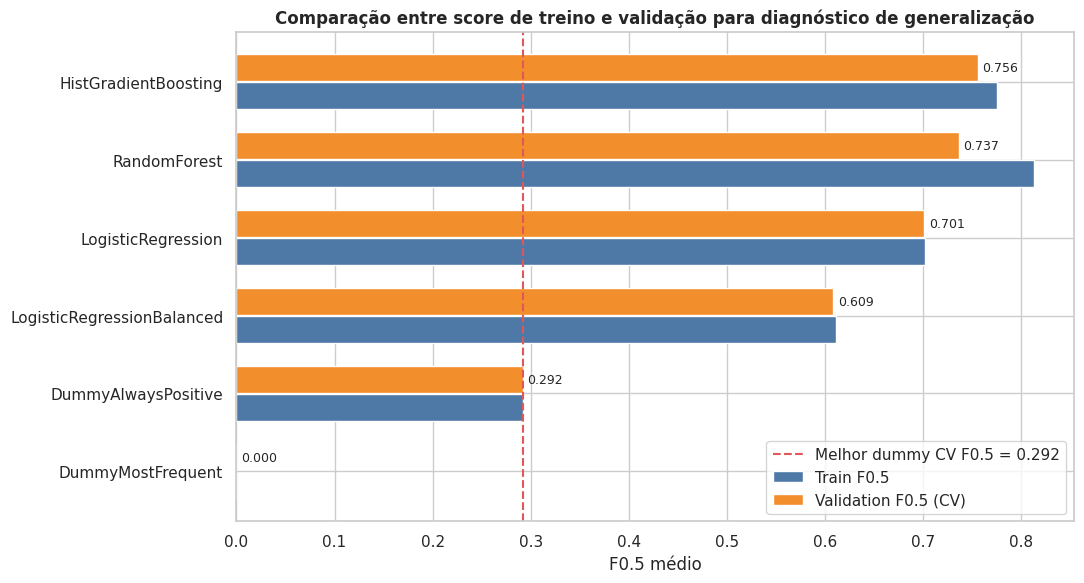

,train_size,train_f0_5_mean,train_f0_5_std,val_f0_5_mean,val_f0_5_std,gap_f0_5,bias_proxy,variance_proxy,diagnosis
0,2894,0.821226,0.008189,0.723079,0.009108,0.098147,0.178774,0.098147,variance moderada
1,8103,0.801027,0.009332,0.741595,0.009333,0.059432,0.198973,0.059432,variance moderada
2,13312,0.780613,0.005673,0.748748,0.009005,0.031865,0.219387,0.031865,generalizacao saudavel
3,18522,0.778433,0.003301,0.750004,0.007749,0.028430,0.221567,0.028430,generalizacao saudavel
4,23731,0.778039,0.003161,0.754829,0.011721,0.023211,0.221961,0.023211,generalizacao saudavel
5,28941,0.776157,0.002111,0.753547,0.010291,0.022610,0.223843,0.022610,generalizacao saudavel


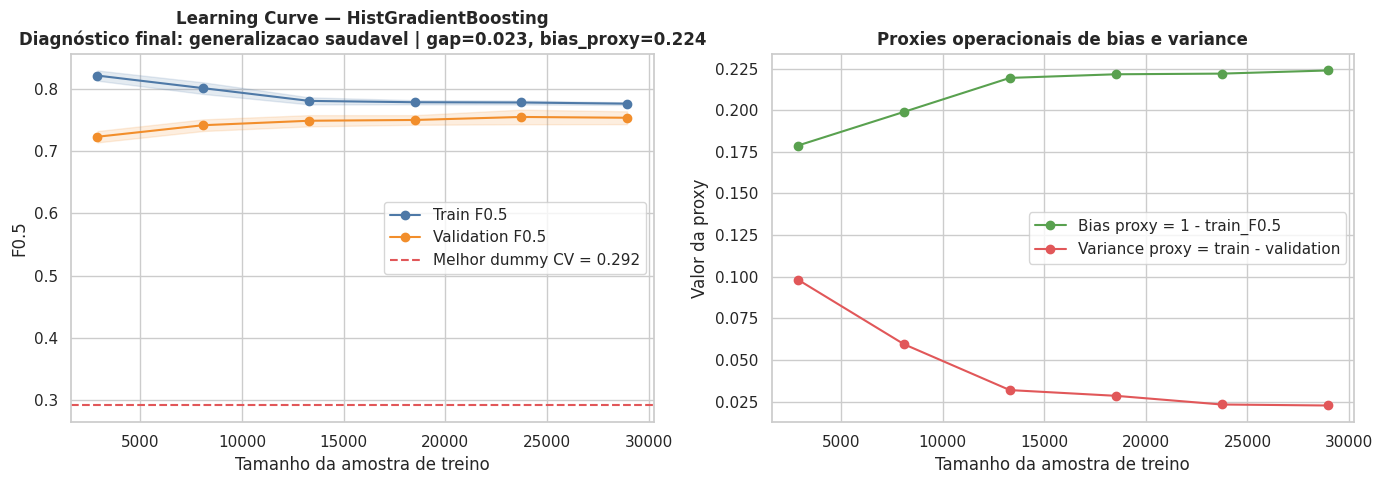

,train_size,train_f0_5_mean,train_f0_5_std,val_f0_5_mean,val_f0_5_std,gap_f0_5,bias_proxy,variance_proxy,diagnosis
0,2894,0.831587,0.009106,0.718317,0.012308,0.113270,0.168413,0.113270,alta variance / overfitting
1,8103,0.821978,0.007925,0.730370,0.009727,0.091608,0.178022,0.091608,variance moderada
2,13312,0.819247,0.006269,0.733695,0.011060,0.085552,0.180753,0.085552,variance moderada
3,18522,0.816232,0.003691,0.733474,0.013112,0.082758,0.183768,0.082758,variance moderada
4,23731,0.815801,0.002248,0.734484,0.013276,0.081317,0.184199,0.081317,variance moderada
5,28941,0.813698,0.002510,0.738234,0.011368,0.075464,0.186302,0.075464,variance moderada


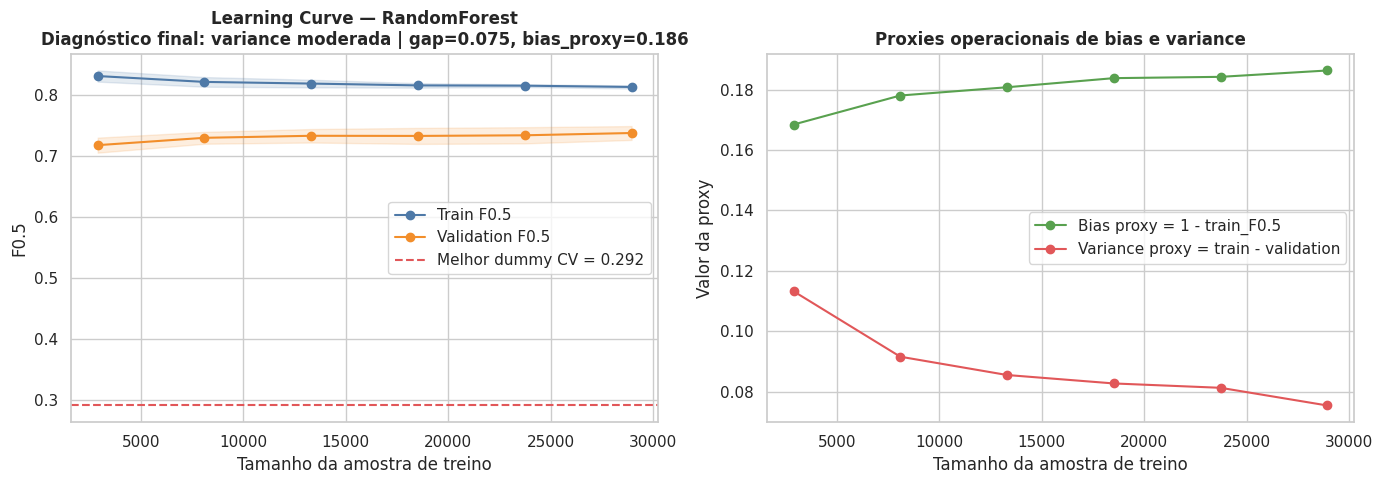

Melhor baseline dummy em CV (F0.5): 0.2917
Modelo campeão da etapa de Modeling: HistGradientBoosting
Modelo adicional exibido para diagnóstico visual de overfitting/underfitting: RandomForest
O conjunto de teste segue preservado e será usado apenas na seção 05 para avaliação final.


In [ ]:
# Modelagem com pipelines e validação estratificada
from sklearn.base import clone
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    fbeta_score,
    make_scorer,
    precision_score,
    recall_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, learning_curve
from sklearn.pipeline import Pipeline

BETA = 0.5
CV_SPLITS = 5

# Nesta etapa usamos a versão principal, sem variáveis sensíveis, mas mantemos o teste intocado.
X_train_model = prepared_datasets["production_safe"]["X_train_raw"].copy()
X_test_model = prepared_datasets["production_safe"]["X_test_raw"].copy()
model_numeric_features = prepared_datasets["production_safe"]["numeric_features"]
model_categorical_features = prepared_datasets["production_safe"][
    "categorical_features"
]


def compute_fbeta_from_precision_recall(precision, recall, beta=BETA):
    """Calcula F-beta a partir de precision e recall já conhecidos.

    Esta função é útil para documentar explicitamente o baseline analítico
    "sempre positivo", em que precision e recall podem ser derivados sem
    ajuste de modelo.
    """
    beta2 = beta**2
    denominator = beta2 * precision + recall
    if denominator == 0:
        return 0.0
    return (1 + beta2) * (precision * recall) / denominator


positive_rate_train = y_train.mean()
naive_positive_precision = positive_rate_train
naive_positive_recall = 1.0
naive_positive_accuracy = positive_rate_train
naive_positive_f0_5 = compute_fbeta_from_precision_recall(
    naive_positive_precision, naive_positive_recall
)

naive_positive_benchmark = pd.DataFrame(
    [
        {
            "model_name": "NaivePositiveAnalytical",
            "family": "benchmark",
            "validation_scheme": "analytical_train_prior",
            "f0_5": naive_positive_f0_5,
            "precision": naive_positive_precision,
            "recall": naive_positive_recall,
            "accuracy": naive_positive_accuracy,
            "notes": "Prediz sempre a classe positiva; precisão = prevalência da classe >50K no treino.",
        }
    ]
)

display(naive_positive_benchmark)

scoring = {
    "f0_5": make_scorer(fbeta_score, beta=BETA, zero_division=0),
    "precision": make_scorer(precision_score, zero_division=0),
    "recall": make_scorer(recall_score, zero_division=0),
    "accuracy": make_scorer(accuracy_score),
}

cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)


def make_modeling_pipeline(estimator):
    """Encapsula preprocessing e estimador em um único Pipeline.

    A construção dentro desta função garante que todo modelo candidato use
    exatamente o mesmo fluxo de transformação, inclusive dentro dos folds de
    cross-validation, evitando leakage e facilitando comparação justa.
    """
    return Pipeline(
        steps=[
            (
                "preprocess",
                build_preprocessor(model_numeric_features, model_categorical_features),
            ),
            ("model", estimator),
        ]
    )


model_catalog = {
    "DummyMostFrequent": {
        "family": "benchmark",
        "rationale": "Referencia de acuracia sob desbalanceamento.",
        "pipeline": make_modeling_pipeline(DummyClassifier(strategy="most_frequent")),
    },
    "DummyAlwaysPositive": {
        "family": "benchmark",
        "rationale": "Versao scikit-learn do baseline sempre positivo.",
        "pipeline": make_modeling_pipeline(
            DummyClassifier(strategy="constant", constant=1)
        ),
    },
    "LogisticRegression": {
        "family": "candidate",
        "rationale": "Baseline supervisionado interpretavel para medir sinal linear apos o preprocessing.",
        "pipeline": make_modeling_pipeline(
            LogisticRegression(
                max_iter=2000, solver="liblinear", random_state=RANDOM_STATE
            )
        ),
    },
    "LogisticRegressionBalanced": {
        "family": "candidate",
        "rationale": "Teste controlado do efeito de class_weight='balanced' em base moderadamente desbalanceada.",
        "pipeline": make_modeling_pipeline(
            LogisticRegression(
                max_iter=2000,
                solver="liblinear",
                class_weight="balanced",
                random_state=RANDOM_STATE,
            )
        ),
    },
    "RandomForest": {
        "family": "candidate",
        "rationale": "Modelo robusto para interacoes e nao linearidades, com regularizacao por leaf minima.",
        "pipeline": make_modeling_pipeline(
            RandomForestClassifier(
                n_estimators=400,
                min_samples_leaf=2,
                min_samples_split=10,
                random_state=RANDOM_STATE,
                n_jobs=1,
            )
        ),
    },
    "HistGradientBoosting": {
        "family": "candidate",
        "rationale": "Boosting moderno e eficiente para tabular, adequado ao tamanho da base e a padroes nao lineares.",
        "pipeline": make_modeling_pipeline(
            HistGradientBoostingClassifier(
                learning_rate=0.05,
                max_depth=6,
                max_iter=250,
                min_samples_leaf=20,
                random_state=RANDOM_STATE,
            )
        ),
    },
}

cv_results_raw = {}
summary_rows = []
fold_rows = []

for model_name, spec in model_catalog.items():
    cv_output = cross_validate(
        estimator=spec["pipeline"],
        X=X_train_model,
        y=y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=True,
        n_jobs=-1,
        error_score="raise",
    )
    cv_results_raw[model_name] = cv_output

    train_f0_5_mean = float(np.mean(cv_output["train_f0_5"]))
    val_f0_5_mean = float(np.mean(cv_output["test_f0_5"]))
    gap_f0_5 = train_f0_5_mean - val_f0_5_mean

    summary_rows.append(
        {
            "model_name": model_name,
            "family": spec["family"],
            "rationale": spec["rationale"],
            "fit_time_mean": float(np.mean(cv_output["fit_time"])),
            "score_time_mean": float(np.mean(cv_output["score_time"])),
            "train_f0_5_mean": train_f0_5_mean,
            "train_f0_5_std": float(np.std(cv_output["train_f0_5"])),
            "val_f0_5_mean": val_f0_5_mean,
            "val_f0_5_std": float(np.std(cv_output["test_f0_5"])),
            "generalization_gap_f0_5": gap_f0_5,
            "val_precision_mean": float(np.mean(cv_output["test_precision"])),
            "val_precision_std": float(np.std(cv_output["test_precision"])),
            "val_recall_mean": float(np.mean(cv_output["test_recall"])),
            "val_recall_std": float(np.std(cv_output["test_recall"])),
            "val_accuracy_mean": float(np.mean(cv_output["test_accuracy"])),
            "val_accuracy_std": float(np.std(cv_output["test_accuracy"])),
        }
    )

    for fold_idx in range(CV_SPLITS):
        fold_rows.append(
            {
                "model_name": model_name,
                "family": spec["family"],
                "fold": fold_idx + 1,
                "train_f0_5": float(cv_output["train_f0_5"][fold_idx]),
                "val_f0_5": float(cv_output["test_f0_5"][fold_idx]),
                "val_precision": float(cv_output["test_precision"][fold_idx]),
                "val_recall": float(cv_output["test_recall"][fold_idx]),
                "val_accuracy": float(cv_output["test_accuracy"][fold_idx]),
            }
        )

modeling_summary = pd.DataFrame(summary_rows)
cv_fold_results = pd.DataFrame(fold_rows)

best_dummy_cv_f0_5 = modeling_summary.loc[
    modeling_summary["family"] == "benchmark", "val_f0_5_mean"
].max()

modeling_summary["gain_vs_best_dummy_f0_5"] = (
    modeling_summary["val_f0_5_mean"] - best_dummy_cv_f0_5
)


def diagnose_generalization(row):
    """Produz um diagnóstico heurístico de generalização por modelo.

    O objetivo não é substituir análise estatística formal, mas dar ao leitor
    uma interpretação operacional imediata sobre underfitting, overfitting e
    ganho efetivo sobre os benchmarks ingênuos.
    """
    if row["family"] == "benchmark":
        return "benchmark"
    if row["val_f0_5_mean"] <= best_dummy_cv_f0_5 + 0.03:
        return "underfitting ou ganho insuficiente sobre baseline"
    if row["generalization_gap_f0_5"] >= 0.10:
        return "overfitting forte"
    if row["generalization_gap_f0_5"] >= 0.05:
        return "sinal moderado de overfitting"
    return "generalizacao estavel"


modeling_summary["diagnosis"] = modeling_summary.apply(diagnose_generalization, axis=1)

benchmark_summary = pd.concat(
    [
        naive_positive_benchmark,
        modeling_summary.loc[
            modeling_summary["family"] == "benchmark",
            [
                "model_name",
                "family",
                "val_f0_5_mean",
                "val_precision_mean",
                "val_recall_mean",
                "val_accuracy_mean",
                "diagnosis",
            ],
        ].rename(
            columns={
                "val_f0_5_mean": "f0_5",
                "val_precision_mean": "precision",
                "val_recall_mean": "recall",
                "val_accuracy_mean": "accuracy",
            }
        ),
    ],
    ignore_index=True,
    sort=False,
)

candidate_results = (
    modeling_summary.loc[modeling_summary["family"] == "candidate"]
    .sort_values(
        by=["val_f0_5_mean", "val_precision_mean", "generalization_gap_f0_5"],
        ascending=[False, False, True],
    )
    .reset_index(drop=True)
)

best_model_name = candidate_results.loc[0, "model_name"]

trained_pipelines = {}
for model_name, spec in model_catalog.items():
    trained_pipelines[model_name] = clone(spec["pipeline"]).fit(X_train_model, y_train)

best_model_pipeline = trained_pipelines[best_model_name]


def learning_curve_diagnosis(row, baseline_f0_5):
    """Interpreta cada ponto da learning curve com foco em bias/variance.

    A leitura combina duas referências práticas: desempenho absoluto frente ao
    melhor dummy e distância entre treino e validação.
    """
    if row["val_f0_5_mean"] <= baseline_f0_5 + 0.03:
        return "alto bias / underfitting"
    if row["gap_f0_5"] >= 0.10:
        return "alta variance / overfitting"
    if row["gap_f0_5"] >= 0.05:
        return "variance moderada"
    return "generalizacao saudavel"


def compute_learning_curve_summary(model_name, train_sizes_fraction=None):
    """Calcula learning curve e deriva proxies operacionais de bias/variance.

    Retorna uma tabela pronta para inspeção analítica, com médias e desvios
    de treino/validação ao longo do crescimento da amostra.
    """
    if train_sizes_fraction is None:
        train_sizes_fraction = np.linspace(0.1, 1.0, 6)

    pipeline = clone(model_catalog[model_name]["pipeline"])
    train_sizes_abs, train_scores, val_scores = learning_curve(  # pyright: ignore[reportAssignmentType]
        estimator=pipeline,
        X=X_train_model,
        y=y_train,
        train_sizes=train_sizes_fraction,
        cv=cv,
        scoring=scoring["f0_5"],
        n_jobs=-1,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    summary = pd.DataFrame(
        {
            "train_size": train_sizes_abs,
            "train_f0_5_mean": np.mean(train_scores, axis=1),
            "train_f0_5_std": np.std(train_scores, axis=1),
            "val_f0_5_mean": np.mean(val_scores, axis=1),
            "val_f0_5_std": np.std(val_scores, axis=1),
        }
    )
    summary["gap_f0_5"] = summary["train_f0_5_mean"] - summary["val_f0_5_mean"]
    summary["bias_proxy"] = 1 - summary["train_f0_5_mean"]
    summary["variance_proxy"] = summary["gap_f0_5"]
    summary["diagnosis"] = summary.apply(
        lambda row: learning_curve_diagnosis(row, best_dummy_cv_f0_5), axis=1
    )
    return summary


def plot_learning_curve_dashboard(summary_df, model_name, baseline_f0_5, subtitle):
    """Plota um painel com learning curve e proxies de bias/variance.

    O painel foi desenhado para fins didáticos: a figura da esquerda mostra o
    comportamento de generalização; a da direita resume a leitura conceitual
    de bias e variance em proxies observáveis no workflow.
    """
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    ax = axes[0]
    ax.plot(
        summary_df["train_size"],
        summary_df["train_f0_5_mean"],
        marker="o",
        color="#4E79A7",
        label="Train F0.5",
    )
    ax.fill_between(
        summary_df["train_size"],
        summary_df["train_f0_5_mean"] - summary_df["train_f0_5_std"],
        summary_df["train_f0_5_mean"] + summary_df["train_f0_5_std"],
        color="#4E79A7",
        alpha=0.15,
    )
    ax.plot(
        summary_df["train_size"],
        summary_df["val_f0_5_mean"],
        marker="o",
        color="#F28E2B",
        label="Validation F0.5",
    )
    ax.fill_between(
        summary_df["train_size"],
        summary_df["val_f0_5_mean"] - summary_df["val_f0_5_std"],
        summary_df["val_f0_5_mean"] + summary_df["val_f0_5_std"],
        color="#F28E2B",
        alpha=0.15,
    )
    ax.axhline(
        baseline_f0_5,
        linestyle="--",
        linewidth=1.5,
        color="#E15759",
        label=f"Melhor dummy CV = {baseline_f0_5:.3f}",
    )
    ax.set_title(f"Learning Curve — {model_name}\n{subtitle}", fontweight="bold")
    ax.set_xlabel("Tamanho da amostra de treino")
    ax.set_ylabel("F0.5")
    ax.legend()

    ax = axes[1]
    ax.plot(
        summary_df["train_size"],
        summary_df["bias_proxy"],
        marker="o",
        color="#59A14F",
        label="Bias proxy = 1 - train_F0.5",
    )
    ax.plot(
        summary_df["train_size"],
        summary_df["variance_proxy"],
        marker="o",
        color="#E15759",
        label="Variance proxy = train - validation",
    )
    ax.set_title("Proxies operacionais de bias e variance", fontweight="bold")
    ax.set_xlabel("Tamanho da amostra de treino")
    ax.set_ylabel("Valor da proxy")
    ax.legend()

    plt.tight_layout()
    plt.show()


learning_curve_artifacts = {}
learning_curve_artifacts[best_model_name] = compute_learning_curve_summary(
    best_model_name
)

problematic_models = candidate_results.loc[
    candidate_results["diagnosis"].isin(
        [
            "underfitting ou ganho insuficiente sobre baseline",
            "overfitting forte",
            "sinal moderado de overfitting",
        ]
    ),
    "model_name",
]

if len(problematic_models) > 0 and problematic_models.iloc[0] != best_model_name:
    diagnostic_model_name = problematic_models.iloc[0]
    learning_curve_artifacts[diagnostic_model_name] = compute_learning_curve_summary(
        diagnostic_model_name
    )
else:
    diagnostic_model_name = best_model_name

display(benchmark_summary)
display(
    modeling_summary.sort_values(
        by=["family", "val_f0_5_mean"], ascending=[True, False]
    )
)
display(cv_fold_results.sort_values(["model_name", "fold"]).reset_index(drop=True))
display(candidate_results)

plot_df = modeling_summary.sort_values("val_f0_5_mean").reset_index(drop=True)
y_positions = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(11, 6))
ax.barh(
    y_positions - 0.18,
    plot_df["train_f0_5_mean"],
    height=0.35,
    color="#4E79A7",
    label="Train F0.5",
)
ax.barh(
    y_positions + 0.18,
    plot_df["val_f0_5_mean"],
    height=0.35,
    color="#F28E2B",
    label="Validation F0.5 (CV)",
)
ax.axvline(
    best_dummy_cv_f0_5,
    linestyle="--",
    linewidth=1.5,
    color="#E15759",
    label=f"Melhor dummy CV F0.5 = {best_dummy_cv_f0_5:.3f}",
)

for idx, value in enumerate(plot_df["val_f0_5_mean"]):
    ax.text(value + 0.005, idx + 0.18, f"{value:.3f}", va="center", fontsize=9)

ax.set_yticks(y_positions)
ax.set_yticklabels(plot_df["model_name"])
ax.set_xlabel("F0.5 médio")
ax.set_title(
    "Comparação entre score de treino e validação para diagnóstico de generalização",
    fontweight="bold",
)
ax.legend()
plt.tight_layout()
plt.show()

for current_model_name, summary_df in learning_curve_artifacts.items():
    last_row = summary_df.iloc[-1]
    subtitle = (
        f"Diagnóstico final: {last_row['diagnosis']} | "
        f"gap={last_row['gap_f0_5']:.3f}, bias_proxy={last_row['bias_proxy']:.3f}"
    )
    display(summary_df)
    plot_learning_curve_dashboard(
        summary_df,
        current_model_name,
        best_dummy_cv_f0_5,
        subtitle,
    )

print(f"Melhor baseline dummy em CV (F0.5): {best_dummy_cv_f0_5:.4f}")
print(f"Modelo campeão da etapa de Modeling: {best_model_name}")
if diagnostic_model_name != best_model_name:
    print(
        f"Modelo adicional exibido para diagnóstico visual de overfitting/underfitting: {diagnostic_model_name}"
    )
print(
    "O conjunto de teste segue preservado e será usado apenas na seção 05 para avaliação final."
)


## 4.2 Otimização de Hiperparâmetros do Modelo Campeão

### O que é holdout e por que ele importa aqui?
**Holdout** é um subconjunto de dados separado antes da etapa de seleção e ajuste do modelo. Neste notebook, o holdout corresponde a `X_test_model` e `y_test`. Ele não deve ser usado para escolher algoritmo, hiperparâmetros nem threshold. Seu papel é funcionar como uma **amostra final honesta**, usada apenas no fim para estimar a capacidade de generalização.

Em outras palavras:
- `treino + validação cruzada` servem para aprender, comparar modelos e ajustar hiperparâmetros;
- `holdout` serve para responder: *"depois de todas as escolhas, como o modelo se comporta em dados realmente preservados?"*

### Estratégia de tuning adotada
- primeiro escolhemos a **família vencedora** com base na validação cruzada da etapa de Modeling;
- em seguida, fazemos **otimização de hiperparâmetros somente no treino**, sem tocar no holdout;
- para modelos de boosting, `learning_rate` e `max_depth` são especialmente relevantes porque controlam, respectivamente, a velocidade de aprendizado e a complexidade das árvores;
- quando o campeão pertence a outra família, o notebook adapta a busca para hiperparâmetros equivalentes de complexidade e regularização.


In [42]:
# Definição da estratégia e do espaço de busca para o campeão
from sklearn.model_selection import RandomizedSearchCV


def get_tuning_setup(model_name):
    """Retorna o espaço de busca do campeão de forma didática.

    A função adapta a busca ao tipo de modelo escolhido em `Modeling`,
    preservando a coerência entre família do algoritmo e hiperparâmetros
    realmente disponíveis na API do scikit-learn.
    """
    if model_name == "HistGradientBoosting":
        return {
            "search_method": "RandomizedSearchCV",
            "n_iter": 24,
            "param_distributions": {
                "model__learning_rate": [0.01, 0.03, 0.05, 0.07, 0.10, 0.15],
                "model__max_depth": [3, 4, 5, 6, 8, None],
                "model__max_iter": [100, 150, 200, 250, 350],
                "model__min_samples_leaf": [10, 20, 30, 50],
                "model__l2_regularization": [0.0, 0.01, 0.10, 1.0],
            },
            "space_rows": [
                {
                    "hyperparameter": "learning_rate",
                    "candidate_values": "0.01, 0.03, 0.05, 0.07, 0.10, 0.15",
                    "didactic_role": "Controla o tamanho do passo de aprendizado; valores menores tendem a generalizar melhor, porém exigem mais iterações.",
                },
                {
                    "hyperparameter": "max_depth",
                    "candidate_values": "3, 4, 5, 6, 8, None",
                    "didactic_role": "Controla a complexidade das árvores-base e afeta diretamente o equilíbrio entre bias e variance.",
                },
                {
                    "hyperparameter": "max_iter",
                    "candidate_values": "100, 150, 200, 250, 350",
                    "didactic_role": "Número de estágios do boosting; interage com `learning_rate`.",
                },
                {
                    "hyperparameter": "min_samples_leaf",
                    "candidate_values": "10, 20, 30, 50",
                    "didactic_role": "Regulariza as folhas e evita ajustes excessivamente locais.",
                },
                {
                    "hyperparameter": "l2_regularization",
                    "candidate_values": "0.0, 0.01, 0.10, 1.0",
                    "didactic_role": "Adiciona regularização extra para reduzir variância.",
                },
            ],
        }

    if model_name == "RandomForest":
        return {
            "search_method": "RandomizedSearchCV",
            "n_iter": 20,
            "param_distributions": {
                "model__n_estimators": [200, 300, 400, 600],
                "model__max_depth": [4, 6, 8, 12, None],
                "model__min_samples_leaf": [1, 2, 4, 8],
                "model__min_samples_split": [2, 5, 10, 20],
                "model__max_features": ["sqrt", "log2", None],
            },
            "space_rows": [
                {
                    "hyperparameter": "max_depth",
                    "candidate_values": "4, 6, 8, 12, None",
                    "didactic_role": "Profundidade máxima das árvores; hiperparâmetro central de complexidade.",
                },
                {
                    "hyperparameter": "n_estimators",
                    "candidate_values": "200, 300, 400, 600",
                    "didactic_role": "Número de árvores do ensemble; reduz variância ao custo de tempo de treino.",
                },
                {
                    "hyperparameter": "min_samples_leaf",
                    "candidate_values": "1, 2, 4, 8",
                    "didactic_role": "Regulariza folhas pequenas e reduz sobreajuste.",
                },
                {
                    "hyperparameter": "min_samples_split",
                    "candidate_values": "2, 5, 10, 20",
                    "didactic_role": "Controla o mínimo necessário para dividir nós internos.",
                },
                {
                    "hyperparameter": "max_features",
                    "candidate_values": "sqrt, log2, None",
                    "didactic_role": "Controla o subconjunto de variáveis elegível em cada divisão.",
                },
            ],
        }

    return {
        "search_method": "RandomizedSearchCV",
        "n_iter": 12,
        "param_distributions": {
            "model__C": [0.01, 0.05, 0.10, 0.50, 1.0, 2.0, 5.0, 10.0],
        },
        "space_rows": [
            {
                "hyperparameter": "C",
                "candidate_values": "0.01, 0.05, 0.10, 0.50, 1.0, 2.0, 5.0, 10.0",
                "didactic_role": "Controla a força de regularização do modelo linear; valores menores implicam regularização mais forte.",
            },
        ],
    }


tuning_base_model_name = best_model_name
tuning_base_pipeline = clone(model_catalog[tuning_base_model_name]["pipeline"])  # pyright: ignore[reportArgumentType]
tuning_setup = get_tuning_setup(tuning_base_model_name)
tuning_search_space_df = pd.DataFrame(tuning_setup["space_rows"])

display(tuning_search_space_df)
print(f"Modelo escolhido para tuning: {tuning_base_model_name}")
print(f"Método de busca: {tuning_setup['search_method']}")
print(f"Número de combinações amostradas: {tuning_setup['n_iter']}")


,hyperparameter,candidate_values,didactic_role
0,learning_rate,"0.01, 0.03, 0.05, 0.07, 0.10, 0.15",Controla o tamanho do passo de aprendizado; va...
1,max_depth,"3, 4, 5, 6, 8, None",Controla a complexidade das árvores-base e afe...
2,max_iter,"100, 150, 200, 250, 350",Número de estágios do boosting; interage com `...
3,min_samples_leaf,"10, 20, 30, 50",Regulariza as folhas e evita ajustes excessiva...
4,l2_regularization,"0.0, 0.01, 0.10, 1.0",Adiciona regularização extra para reduzir vari...


Modelo escolhido para tuning: HistGradientBoosting
Método de busca: RandomizedSearchCV
Número de combinações amostradas: 24


### Como ler a etapa de busca
`RandomizedSearchCV` sorteia combinações do espaço de hiperparâmetros e avalia cada combinação com validação cruzada estratificada. Aqui, o objetivo não é apenas "achar o maior score", mas entender **como a performance reage à complexidade do modelo**.

Nesta etapa, o holdout continua intocado. Toda a seleção ainda acontece somente sobre o conjunto de treino.


Fitting 5 folds for each of 24 candidates, totalling 120 fits


,mean_fit_time,param_model__min_samples_leaf,param_model__max_iter,param_model__max_depth,param_model__learning_rate,param_model__l2_regularization,mean_test_score,std_test_score,rank_test_score,mean_train_score,std_train_score
0,3.566646,20,250,4,0.05,1.00,0.754959,0.011804,1,0.765514,0.003641
1,3.129404,50,250,3,0.10,0.01,0.754869,0.010995,2,0.765816,0.003683
2,3.095457,30,200,5,0.07,0.01,0.754557,0.009292,3,0.771290,0.003531
3,3.518576,30,350,4,0.10,0.01,0.754176,0.010644,4,0.772533,0.004683
4,4.869263,30,350,6,0.03,0.10,0.754035,0.009388,5,0.772330,0.003570
5,3.432092,10,150,None,0.07,0.01,0.753643,0.009156,6,0.777242,0.003272
6,2.720368,30,250,8,0.10,0.01,0.752810,0.008963,7,0.779245,0.001626
7,2.465082,50,250,3,0.07,0.01,0.752186,0.012889,8,0.760735,0.003585
8,3.578763,30,200,8,0.05,0.00,0.751926,0.009858,9,0.774933,0.002486
9,2.152587,50,250,8,0.15,0.10,0.751751,0.011461,10,0.780469,0.005250


Melhor score médio de validação (F0.5): 0.7550
Melhores hiperparâmetros: {'model__min_samples_leaf': 20, 'model__max_iter': 250, 'model__max_depth': 4, 'model__learning_rate': 0.05, 'model__l2_regularization': 1.0}


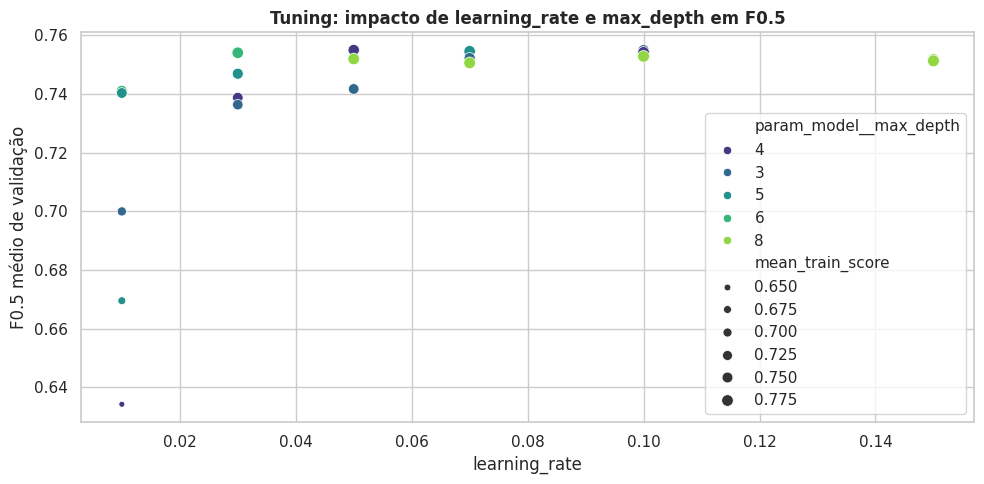

In [43]:
# Busca de hiperparâmetros com validação cruzada estratificada
tuning_search = RandomizedSearchCV(
    estimator=tuning_base_pipeline,
    param_distributions=tuning_setup["param_distributions"],
    n_iter=tuning_setup["n_iter"],
    scoring=scoring["f0_5"],
    cv=cv,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    refit=True,
    return_train_score=True,
    verbose=1,
)

tuning_search.fit(X_train_model, y_train)

tuning_results = (
    pd.DataFrame(tuning_search.cv_results_)
    .sort_values(
        ["rank_test_score", "mean_test_score"],
        ascending=[True, False],
    )
    .reset_index(drop=True)
)

tuning_results_top = tuning_results[
    [
        col
        for col in tuning_results.columns
        if col.startswith("param_")
        or col
        in [
            "rank_test_score",
            "mean_test_score",
            "std_test_score",
            "mean_train_score",
            "std_train_score",
            "mean_fit_time",
        ]
    ]
].head(10)

display(tuning_results_top)
print(f"Melhor score médio de validação (F0.5): {tuning_search.best_score_:.4f}")
print(f"Melhores hiperparâmetros: {tuning_search.best_params_}")

if {"param_model__learning_rate", "param_model__max_depth"}.issubset(
    tuning_results.columns
):
    plot_df = tuning_results.copy()
    plot_df["param_model__learning_rate"] = plot_df[
        "param_model__learning_rate"
    ].astype(float)
    plot_df["param_model__max_depth"] = plot_df["param_model__max_depth"].astype(str)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.scatterplot(
        data=plot_df,
        x="param_model__learning_rate",
        y="mean_test_score",
        hue="param_model__max_depth",
        size="mean_train_score",
        palette="viridis",
        ax=ax,
    )
    ax.set_title(
        "Tuning: impacto de learning_rate e max_depth em F0.5", fontweight="bold"
    )
    ax.set_xlabel("learning_rate")
    ax.set_ylabel("F0.5 médio de validação")
    plt.tight_layout()
    plt.show()


### Comparação entre campeão original e campeão otimizado
Depois da busca, o melhor estimador encontrado é reavaliado por validação cruzada para responder uma pergunta importante para o leitor: **o tuning realmente melhorou o modelo ou apenas encontrou uma variação equivalente?**

Essa comparação ainda acontece antes do holdout e serve para justificar por que o pipeline otimizado passa a ser o candidato principal da seção `Evaluation`.


,model_name,family,fit_time_mean,train_f0_5_mean,val_f0_5_mean,generalization_gap_f0_5,val_precision_mean,val_recall_mean,val_accuracy_mean
0,HistGradientBoosting,candidate,2.190829,0.775405,0.755772,0.019633,0.790031,0.644212,0.869364
1,HistGradientBoosting tuned,candidate_tuned,1.668973,0.765514,0.754959,0.010554,0.799049,0.618558,0.866877


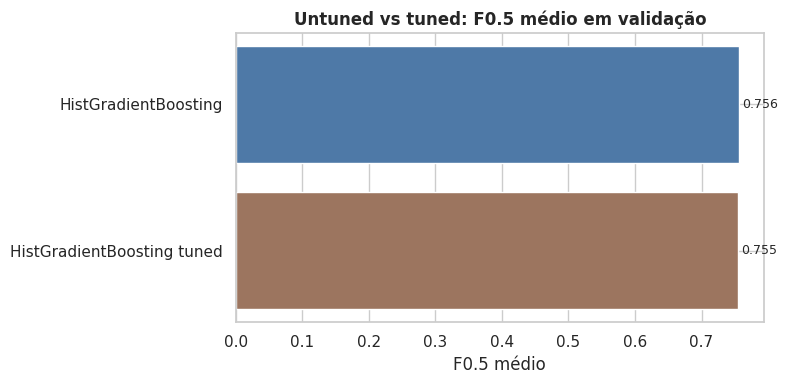

Modelo encaminhado para Evaluation: HistGradientBoosting tuned
O holdout continua preservado e ainda não foi usado nesta etapa de tuning.


In [44]:
# Comparação entre o campeão original e a versão otimizada
tuned_best_model_name = f"{tuning_base_model_name} tuned"
tuned_best_model_pipeline = tuning_search.best_estimator_

tuned_cv_output = cross_validate(
    tuned_best_model_pipeline,
    X_train_model,
    y_train,
    cv=cv,
    scoring=scoring,
    return_train_score=True,
    n_jobs=-1,
    error_score="raise",
)

tuned_best_model_summary = pd.DataFrame(
    [
        {
            "model_name": tuned_best_model_name,
            "family": "candidate_tuned",
            "fit_time_mean": float(np.mean(tuned_cv_output["fit_time"])),
            "train_f0_5_mean": float(np.mean(tuned_cv_output["train_f0_5"])),
            "val_f0_5_mean": float(np.mean(tuned_cv_output["test_f0_5"])),
            "generalization_gap_f0_5": float(
                np.mean(tuned_cv_output["train_f0_5"])
                - np.mean(tuned_cv_output["test_f0_5"])
            ),
            "val_precision_mean": float(np.mean(tuned_cv_output["test_precision"])),
            "val_recall_mean": float(np.mean(tuned_cv_output["test_recall"])),
            "val_accuracy_mean": float(np.mean(tuned_cv_output["test_accuracy"])),
        }
    ]
)

untuned_reference_summary = modeling_summary.loc[
    modeling_summary["model_name"] == tuning_base_model_name,
    [
        "model_name",
        "family",
        "fit_time_mean",
        "train_f0_5_mean",
        "val_f0_5_mean",
        "generalization_gap_f0_5",
        "val_precision_mean",
        "val_recall_mean",
        "val_accuracy_mean",
    ],
]

untuned_vs_tuned_summary = pd.concat(
    [untuned_reference_summary, tuned_best_model_summary],
    ignore_index=True,
)

display(untuned_vs_tuned_summary)

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = untuned_vs_tuned_summary[["model_name", "val_f0_5_mean"]].sort_values(
    "val_f0_5_mean"
)
ax.barh(plot_df["model_name"], plot_df["val_f0_5_mean"], color=["#9C755F", "#4E79A7"])
for idx, value in enumerate(plot_df["val_f0_5_mean"]):
    ax.text(value + 0.005, idx, f"{value:.3f}", va="center", fontsize=9)
ax.set_title("Untuned vs tuned: F0.5 médio em validação", fontweight="bold")
ax.set_xlabel("F0.5 médio")
plt.tight_layout()
plt.show()

evaluation_model_name = tuned_best_model_name
evaluation_model_pipeline = tuned_best_model_pipeline

print(f"Modelo encaminhado para Evaluation: {evaluation_model_name}")
print("O holdout continua preservado e ainda não foi usado nesta etapa de tuning.")


<a id="sec05"></a>
# 05 - Evaluation

## Objetivo
Avaliar o modelo campeão em um conjunto de teste preservado, comparando-o com benchmarks ingênuos e verificando se o desempenho observado é consistente com a necessidade de priorizar contatos com maior chance de retorno.

## Protocolo de avaliação
- **holdout** é o conjunto separado antes da escolha do modelo e do tuning; aqui ele corresponde a `X_test_model`, `y_test` e só é tocado nesta seção;
- benchmarks ingênuos continuam presentes para contextualizar o ganho real do pipeline supervisionado;
- o threshold padrão `0.50` é comparado com um threshold ajustado usando apenas predições out-of-fold do treino, preservando a honestidade do teste;
- a leitura final combina métricas, matriz de confusão, tabela de threshold e um rastreio inicial por subgrupos sensíveis apenas para auditoria.

## Perguntas de avaliação respondidas nesta fase
- O modelo supera com folga o baseline ingênuo?
- O ganho veio com precisão suficiente para justificar uso operacional?
- O corte de decisão atual está adequado ao custo de falso positivo?
- Existem sinais de viés ou fragilidade em segmentos específicos?

## Itens implementados
- avaliação final do campeão da etapa de modeling em teste;
- comparação com o melhor `DummyClassifier` e com o baseline analítico sempre positivo;
- seleção de threshold com base em treino por validação cruzada out-of-fold;
- matriz de confusão, relatório de classificação e tabela de métricas em teste;
- rastreio inicial de fragilidade por `sex` e `race` usando atributos apenas para auditoria.


,model_name,threshold,accuracy,precision,recall,f0_5,predicted_positive_rate
0,HistGradientBoosting tuned @train-tuned-threshold,0.5723,0.859370,0.837274,0.537021,0.753065,0.158983
1,HistGradientBoosting tuned @0.50,0.5000,0.861470,0.791054,0.599465,0.743527,0.187839
2,DummyAlwaysPositive @0.50,0.5000,0.247872,0.247872,1.000000,0.291760,1.000000
3,NaivePositiveAnalytical @test,1.0000,0.247872,0.247872,1.000000,0.291760,1.000000


,threshold,precision,recall,f0_5,predicted_positive_rate
4787,0.5723,0.839772,0.557662,0.762614,0.164580
4786,0.5722,0.839657,0.557774,0.762580,0.164635
4931,0.5928,0.854234,0.533348,0.762485,0.154739
4932,0.5929,0.854234,0.533348,0.762485,0.154739
4898,0.5884,0.850484,0.539259,0.762474,0.157144
4784,0.5719,0.839403,0.557885,0.762454,0.164718
4785,0.5721,0.839403,0.557885,0.762454,0.164718
4892,0.5875,0.849825,0.540263,0.762450,0.157559
4897,0.5882,0.850360,0.539371,0.762439,0.157199
4896,0.5881,0.850141,0.539706,0.762431,0.157338


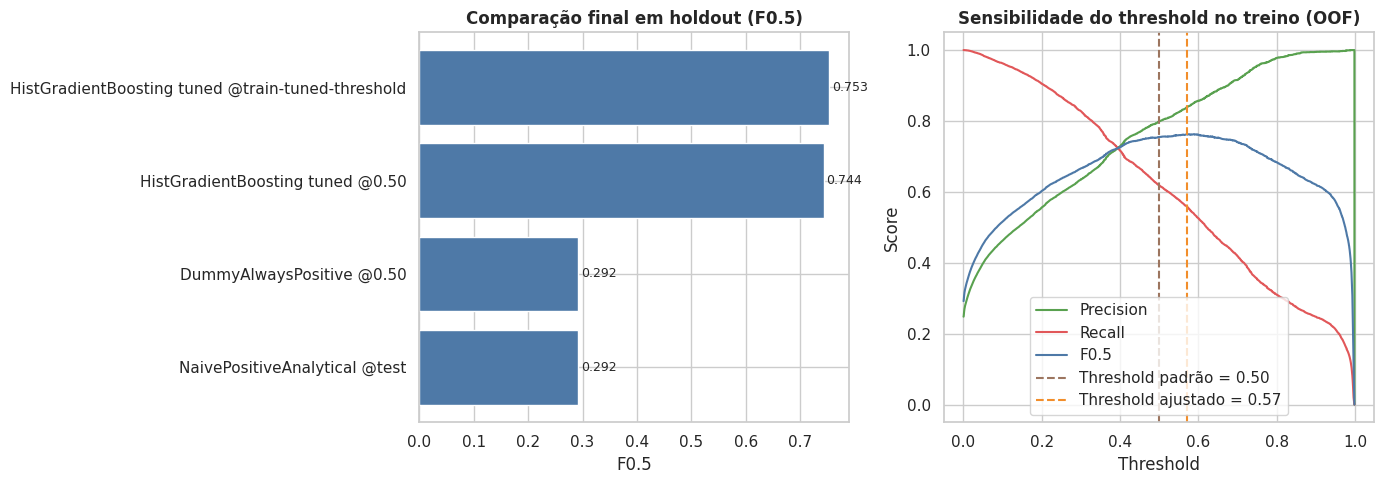

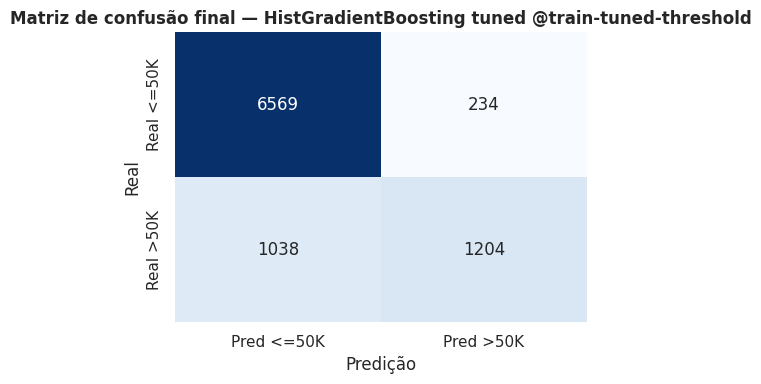

              precision    recall  f1-score   support

       <=50K       0.86      0.97      0.91      6803
        >50K       0.84      0.54      0.65      2242

    accuracy                           0.86      9045
   macro avg       0.85      0.75      0.78      9045
weighted avg       0.86      0.86      0.85      9045



,group,support,actual_positive_rate,predicted_positive_rate,precision,recall,f0_5
0,Male,6061,0.311665,0.206567,0.833866,0.552673,0.756851
1,Female,2984,0.118298,0.062332,0.860215,0.453258,0.729262


,group,support,actual_positive_rate,predicted_positive_rate,precision,recall,f0_5
0,White,7764,0.263653,0.169243,0.841705,0.540303,0.757223
1,Black,849,0.123675,0.068316,0.827586,0.457143,0.712166
2,Asian-Pac-Islander,268,0.272388,0.208955,0.767857,0.589041,0.723906


Modelo campeão avaliado em teste: HistGradientBoosting tuned
Melhor baseline dummy na comparação final: DummyAlwaysPositive
Threshold padrão avaliado: 0.50
Threshold ajustado no treino (OOF): 0.57
Threshold final adotado para leitura da matriz de confusão: 0.57
Resumo final em teste -> F0.5=0.753, precision=0.837, recall=0.537, accuracy=0.859


In [45]:
# Avaliação final em holdout, análise de threshold e auditoria inicial
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_recall_curve,
)
from sklearn.model_selection import cross_val_predict

DEFAULT_THRESHOLD = 0.50
MIN_AUDIT_SUPPORT = 200


def get_positive_scores(estimator, X):
    """Retorna scores da classe positiva para análise de threshold.

    Sempre que possível usa `predict_proba`. Quando isso não estiver
    disponível, faz fallback para `decision_function` normalizado ou para a
    própria predição binária.
    """
    if hasattr(estimator, "predict_proba"):
        return estimator.predict_proba(X)[:, 1]
    if hasattr(estimator, "decision_function"):
        raw_scores = estimator.decision_function(X)
        raw_min = np.min(raw_scores)
        raw_max = np.max(raw_scores)
        if raw_max == raw_min:
            return np.zeros_like(raw_scores, dtype=float)
        return (raw_scores - raw_min) / (raw_max - raw_min)
    return estimator.predict(X).astype(float)


def compute_binary_metrics(y_true, y_pred, beta=BETA):
    """Calcula o conjunto central de métricas binárias do projeto."""
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "f0_5": float(fbeta_score(y_true, y_pred, beta=beta, zero_division=0)),
    }


def evaluate_estimator_at_threshold(estimator, X, y, threshold=0.5, label=None):
    """Avalia um estimador em um threshold específico.

    Retorna métricas resumidas, os scores contínuos e as predições binárias.
    Isso permite reutilizar a mesma avaliação em holdout, baseline e tuning de
    threshold.
    """
    scores = get_positive_scores(estimator, X)
    y_pred = (scores >= threshold).astype(int)
    metrics = compute_binary_metrics(y, y_pred)
    metrics.update(
        {
            "model_name": label,
            "threshold": float(threshold),
            "predicted_positive_rate": float(np.mean(y_pred)),
        }  # pyright: ignore[reportArgumentType]
    )  # type: ignore
    return metrics, scores, y_pred


def get_oof_positive_scores(estimator, X, y):
    """Gera scores out-of-fold no treino para selecionar threshold sem leakage.

    A função recebe diretamente o estimador a ser auditado, o que permite
    reutilizar a mesma lógica tanto para o campeão original quanto para a
    versão otimizada por tuning.
    """
    estimator_template = clone(estimator)
    model_step = estimator_template.named_steps["model"]

    if hasattr(model_step, "predict_proba"):
        return cross_val_predict(
            estimator_template,
            X,
            y,
            cv=cv,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

    if hasattr(model_step, "decision_function"):
        raw_scores = cross_val_predict(
            estimator_template,
            X,
            y,
            cv=cv,
            method="decision_function",
            n_jobs=-1,
        )
        raw_min = np.min(raw_scores)
        raw_max = np.max(raw_scores)
        if raw_max == raw_min:
            return np.zeros_like(raw_scores, dtype=float)
        return (raw_scores - raw_min) / (raw_max - raw_min)

    return cross_val_predict(
        estimator_template,
        X,
        y,
        cv=cv,
        method="predict",
        n_jobs=-1,
    ).astype(float)


def threshold_search_from_scores(y_true, scores, beta=BETA):
    """Busca thresholds candidatos e escolhe o melhor via F0.5 no treino.

    O objetivo é responder se o corte padrão `0.50` está alinhado ao custo de
    falso positivo do problema.
    """
    _pr_precision, _pr_recall, pr_thresholds = precision_recall_curve(y_true, scores)
    candidate_thresholds = np.unique(
        np.round(
            np.concatenate(
                [
                    np.array([0.10, 0.20, 0.30, 0.40, 0.50, 0.60, 0.70, 0.80, 0.90]),
                    pr_thresholds,
                ]
            ),
            4,
        )
    )

    rows = []
    for threshold in candidate_thresholds:
        y_pred = (scores >= threshold).astype(int)
        metrics = compute_binary_metrics(y_true, y_pred, beta=beta)
        rows.append(
            {
                "threshold": float(threshold),
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f0_5": metrics["f0_5"],
                "predicted_positive_rate": float(np.mean(y_pred)),
            }
        )

    threshold_table = pd.DataFrame(rows).sort_values("threshold").reset_index(drop=True)
    best_threshold = threshold_table.sort_values(
        by=["f0_5", "precision", "recall", "threshold"],
        ascending=[False, False, False, False],
    ).iloc[0]["threshold"]
    return threshold_table, float(best_threshold)


def subgroup_audit_table(group_series, y_true, y_pred, min_support=MIN_AUDIT_SUPPORT):
    """Cria um resumo de métricas por grupo para rastreio inicial de fragilidade.

    Esta tabela é um screening operacional e não deve ser tratada como uma
    certificação formal de fairness.
    """
    y_pred_series = pd.Series(y_pred, index=y_true.index)
    rows = []

    for group_name, group_index in group_series.groupby(group_series).groups.items():
        support = len(group_index)
        if support < min_support:
            continue

        group_true = y_true.loc[group_index]
        group_pred = y_pred_series.loc[group_index]
        metrics = compute_binary_metrics(group_true, group_pred)
        rows.append(
            {
                "group": group_name,
                "support": int(support),
                "actual_positive_rate": float(group_true.mean()),
                "predicted_positive_rate": float(group_pred.mean()),
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f0_5": metrics["f0_5"],
            }
        )

    if not rows:
        return pd.DataFrame(
            columns=[
                "group",
                "support",
                "actual_positive_rate",
                "predicted_positive_rate",
                "precision",
                "recall",
                "f0_5",
            ]
        )

    return (
        pd.DataFrame(rows)
        .sort_values("support", ascending=False)
        .reset_index(drop=True)
    )


best_dummy_model_name = (
    modeling_summary.loc[modeling_summary["family"] == "benchmark"]
    .sort_values("val_f0_5_mean", ascending=False)
    .iloc[0]["model_name"]
)

best_dummy_pipeline = trained_pipelines[best_dummy_model_name]

model_for_evaluation_name = (
    evaluation_model_name if "evaluation_model_name" in globals() else best_model_name
)
model_for_evaluation_pipeline = (
    evaluation_model_pipeline
    if "evaluation_model_pipeline" in globals()
    else best_model_pipeline
)

naive_test_precision = float(y_test.mean())
naive_test_recall = 1.0
naive_test_accuracy = float(y_test.mean())
naive_test_f0_5 = compute_fbeta_from_precision_recall(
    naive_test_precision, naive_test_recall
)

naive_test_row = {
    "model_name": "NaivePositiveAnalytical @test",
    "threshold": 1.0,
    "accuracy": naive_test_accuracy,
    "precision": naive_test_precision,
    "recall": naive_test_recall,
    "f0_5": naive_test_f0_5,
    "predicted_positive_rate": 1.0,
}

best_dummy_metrics, _, best_dummy_pred = evaluate_estimator_at_threshold(
    best_dummy_pipeline,
    X_test_model,
    y_test,
    threshold=DEFAULT_THRESHOLD,
    label=f"{best_dummy_model_name} @0.50",
)

best_default_metrics, best_test_scores, best_default_pred = (
    evaluate_estimator_at_threshold(
        model_for_evaluation_pipeline,
        X_test_model,
        y_test,
        threshold=DEFAULT_THRESHOLD,
        label=f"{model_for_evaluation_name} @0.50",
    )
)

best_model_oof_scores = get_oof_positive_scores(
    model_for_evaluation_pipeline,
    X_train_model,
    y_train,
)
threshold_table_train, tuned_threshold = threshold_search_from_scores(
    y_train,
    best_model_oof_scores,
)

best_tuned_metrics, best_test_scores_tuned, best_tuned_pred = (
    evaluate_estimator_at_threshold(
        model_for_evaluation_pipeline,
        X_test_model,
        y_test,
        threshold=tuned_threshold,
        label=f"{model_for_evaluation_name} @train-tuned-threshold",
    )
)

evaluation_test_summary = (
    pd.DataFrame(
        [naive_test_row, best_dummy_metrics, best_default_metrics, best_tuned_metrics]
    )
    .sort_values("f0_5", ascending=False)
    .reset_index(drop=True)
)

final_threshold = (
    tuned_threshold
    if best_tuned_metrics["f0_5"] >= best_default_metrics["f0_5"]
    else DEFAULT_THRESHOLD
)
final_pred = (
    best_tuned_pred if final_threshold == tuned_threshold else best_default_pred
)
final_scores = (
    best_test_scores_tuned if final_threshold == tuned_threshold else best_test_scores
)
final_label = (
    f"{model_for_evaluation_name} @train-tuned-threshold"
    if final_threshold == tuned_threshold
    else f"{model_for_evaluation_name} @0.50"
)

final_metrics = compute_binary_metrics(y_test, final_pred)

display(evaluation_test_summary)
display(threshold_table_train.sort_values("f0_5", ascending=False).head(10))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

comparison_df = evaluation_test_summary.sort_values("f0_5")
axes[0].barh(comparison_df["model_name"], comparison_df["f0_5"], color="#4E79A7")
for idx, value in enumerate(comparison_df["f0_5"]):
    axes[0].text(value + 0.005, idx, f"{value:.3f}", va="center", fontsize=9)
axes[0].set_title("Comparação final em holdout (F0.5)", fontweight="bold")
axes[0].set_xlabel("F0.5")

axes[1].plot(
    threshold_table_train["threshold"],
    threshold_table_train["precision"],
    label="Precision",
    color="#59A14F",
)
axes[1].plot(
    threshold_table_train["threshold"],
    threshold_table_train["recall"],
    label="Recall",
    color="#E15759",
)
axes[1].plot(
    threshold_table_train["threshold"],
    threshold_table_train["f0_5"],
    label="F0.5",
    color="#4E79A7",
)
axes[1].axvline(
    DEFAULT_THRESHOLD, color="#9C755F", linestyle="--", label="Threshold padrão = 0.50"
)
axes[1].axvline(
    tuned_threshold,
    color="#F28E2B",
    linestyle="--",
    label=f"Threshold ajustado = {tuned_threshold:.2f}",
)
axes[1].set_title("Sensibilidade do threshold no treino (OOF)", fontweight="bold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Score")
axes[1].legend()

plt.tight_layout()
plt.show()

cm = confusion_matrix(y_test, final_pred)
fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False,
    xticklabels=["Pred <=50K", "Pred >50K"],
    yticklabels=["Real <=50K", "Real >50K"],
    ax=ax,
)
ax.set_title(f"Matriz de confusão final — {final_label}", fontweight="bold")
ax.set_xlabel("Predição")
ax.set_ylabel("Real")
plt.tight_layout()
plt.show()

print(
    classification_report(
        y_test, final_pred, target_names=["<=50K", ">50K"], zero_division=0
    )
)

test_audit_frame = prep_df.loc[
    test_idx, ["sex", "race", "native-country-grouped"]
].copy()
sex_audit = subgroup_audit_table(test_audit_frame["sex"], y_test, final_pred)
race_audit = subgroup_audit_table(test_audit_frame["race"], y_test, final_pred)

display(sex_audit)
display(race_audit)

print(f"Modelo campeão avaliado em teste: {model_for_evaluation_name}")
print(f"Melhor baseline dummy na comparação final: {best_dummy_model_name}")
print(f"Threshold padrão avaliado: {DEFAULT_THRESHOLD:.2f}")
print(f"Threshold ajustado no treino (OOF): {tuned_threshold:.2f}")
print(
    f"Threshold final adotado para leitura da matriz de confusão: {final_threshold:.2f}"
)
print(
    f"Resumo final em teste -> F0.5={final_metrics['f0_5']:.3f}, "
    f"precision={final_metrics['precision']:.3f}, recall={final_metrics['recall']:.3f}, "
    f"accuracy={final_metrics['accuracy']:.3f}"
)


## Fechamento do Notebook: Resposta às Perguntas Centrais e Próximos Passos

### O que este notebook respondeu ao longo do CRISP-DM
1. **O alvo exigia cuidado especial nas métricas?** Sim. A base mostrou desbalanceamento moderado, o que justificou o uso de `F0.5`, precisão, recall e `stratify` na separação treino/teste.
2. **Quais variáveis realmente separavam a classe positiva?** A EDA mostrou sinal forte em escolaridade, ocupação, idade, horas trabalhadas e eventos de capital; isso orientou diretamente a preparação e a escolha de modelos tabulares não lineares.
3. **Havia assimetria, redundância e categorias raras?** Sim. `capital-gain` e `capital-loss` exigiram tratamento específico; `education_level` e `education-num` mostraram redundância; `native-country` apresentou categorias raras e foi deixada para auditoria.
4. **Variáveis sensíveis precisavam de cuidado adicional?** Sim. `sex`, `race` e `native-country` foram retiradas da trilha principal de modelagem e preservadas apenas para análise de risco e fairness.
5. **O modelo final supera o baseline ingênuo?** A seção de Evaluation responde isso objetivamente por meio do holdout final, comparando o campeão com dummies e com o baseline analítico sempre positivo.

### O que significa inferência neste contexto
**Inferência** é o momento em que um modelo já treinado recebe **novos registros nunca vistos** e produz uma saída útil para decisão. Neste projeto, inferência significa pegar os atributos de uma nova pessoa, aplicar exatamente o mesmo pipeline de preparação e retornar:
- uma **probabilidade** de pertencer à classe `>50K`;
- uma **classe prevista** após aplicar um threshold de decisão;
- um **score** que pode ser usado para ranquear potenciais contatos da CharityML.

Em termos práticos, inferência não é "treinar de novo". É apenas **usar o pipeline já ajustado** para classificar novos casos.

### Como este notebook pode ser usado para utilização do modelo
Este notebook pode servir como:
- **documento analítico completo**, mostrando o raciocínio CRISP-DM de ponta a ponta;
- **base reprodutível de treinamento**, porque a preparação, a seleção do modelo e a avaliação estão explícitas;
- **protótipo de produção**, desde que o pipeline campeão seja serializado (por exemplo com `joblib`) e consumido por uma rotina externa de inferência.

O caminho típico de uso é:
1. treinar e validar o pipeline neste notebook;
2. salvar o pipeline final ajustado;
3. criar uma função ou serviço que receba novos dados e aplique `predict_proba` / `predict`;
4. monitorar desempenho, drift e fairness após o uso real.

### Depois da escolha do melhor modelo, como achar os melhores hiperparâmetros?
A estratégia recomendada é **otimização de hiperparâmetros somente no conjunto de treino**, usando validação cruzada estratificada e mantendo `F0.5` como métrica-alvo. Em workflow sênior de `scikit-learn`, a sequência mais robusta costuma ser:
- **`RandomizedSearchCV`** para explorar uma região ampla de hiperparâmetros com custo computacional controlado;
- opcionalmente, uma segunda passada com **`GridSearchCV`** em torno da região promissora encontrada;
- `refit=True` para que o melhor estimador seja re-treinado automaticamente no conjunto completo de treino.
Essa escolha é melhor do que ir direto para uma grade muito grande, porque evita custo excessivo e costuma encontrar regiões boas com mais eficiência.

### Depois do tuning, o que é feito?
Depois que os melhores hiperparâmetros são encontrados, o fluxo correto é:
1. **reajustar o melhor pipeline no treino completo**;
2. **ajustar o threshold de decisão** usando apenas treino/validação, nunca o teste;
3. **avaliar uma única vez no conjunto de teste** para obter a estimativa final de generalização;
4. **auditar fairness e fragilidade por subgrupos**;
5. **salvar o pipeline final** e preparar a etapa de inferência em novos dados;
6. **monitorar em produção** se a distribuição dos dados e o desempenho se mantêm estáveis.

### Conclusão executiva
Este notebook não é apenas um experimento. Ele foi estruturado para mostrar como um cientista de dados conecta **problema de negócio, entendimento dos dados, preparação, modelagem, avaliação e próximos passos de deployment** de forma coerente. O resultado final mais importante não é apenas "qual modelo ganhou", mas sim **qual processo produziu uma decisão confiável, auditável e reutilizável**.
